<a href="https://colab.research.google.com/github/SpineFairy/myspace/blob/test/%EA%B0%95%ED%99%94%ED%95%99%EC%8A%B5%20%EC%8B%A4%EC%8A%B5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install gymnasium stable-baselines3

# 강화모델 연습

## 라이브러리

In [ ]:
import os, sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client",
    message=".*datetime.datetime.utcnow() is deprecated.*"
)

# gymnasium
try:
    import gymnasium as gym
    from gymnasium import spaces
except Exception:
    raise RuntimeError("gymnasium 필요: `pip install gymnasium` 후 재실행")

import importlib.util
import joblib

# (코랩 경로)
IFRF_PY_PATH = "/content/IFRF.py"
UNIFIED_PKL  = "/content/unified_model (4).pkl"

# display (코랩)
try:
    from IPython.display import display
except Exception:
    display = print

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 유틸

In [ ]:
NORMAL_BAND = {
    "temperature": (27.0, 33.0),
    "humidity":    (40.0, 50.0),
    "vibration":   (2.0,  4.0),
}
SAFE_LIMIT = {
    "temperature": (5.0,  75.0),
    "humidity":    (5.0,  80.0),
    "vibration":   (0.5,  8.0),
}

# 하드 세이프티(임시값): 정상범위보다 넓게 잡아서 "강제정지"는 정말 위험할 때만
SAFE_BAND = {
    "temperature": (25.0, 40.0),
    "humidity":    (30.0, 60.0),
    "vibration":   (1.0,  9.0),
}

def in_band(x, lo, hi):
    return (x >= lo) and (x <= hi)

def band_distance(x, lo, hi):
    if x < lo: return lo - x
    if x > hi: return x - hi
    return 0.0

def entropy_from_proba(p):
    p = np.clip(p, 1e-12, 1.0)
    p = p / p.sum()
    return float(-(p * np.log(p)).sum())

def q(x: float, step: float = 0.1) -> float:
    # 0.1 단위로 반올림
    return float(np.round(x / step) * step)

def band_violation_amount(x: float, lo: float, hi: float) -> float:
    if x < lo:
        return lo - x
    if x > hi:
        return x - hi
    return 0.0

def compute_dist(t: float, h: float, v: float) -> float:
    dt = band_violation_amount(t, *NORMAL_BAND["temperature"])
    dh = band_violation_amount(h, *NORMAL_BAND["humidity"])
    dv = band_violation_amount(v, *NORMAL_BAND["vibration"])
    return dt + dh + dv

## 탐지분류 사용

In [ ]:
def load_unified_model(pkl_path: str, ifrf_py_path: str):
    """
    IFRF.py의 UnifiedModel/UnifiedConfig에 의존
    """
    spec = importlib.util.spec_from_file_location("ifrf_module", ifrf_py_path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules["ifrf_module"] = mod
    spec.loader.exec_module(mod)

    import __main__
    __main__.UnifiedModel = mod.UnifiedModel
    __main__.UnifiedConfig = mod.UnifiedConfig

    # pickle alias (numpy._core) (GPT추론)
    import numpy.core as npcore
    sys.modules.setdefault("numpy._core", npcore)

    return joblib.load(pkl_path)


class UnifiedWrapper:
    """
    unified.predict_raw(df_raw) 실행을 위해 최근 win_size raw 버퍼 유지.
    """
    def __init__(self, unified):
        self.unified = unified
        self.win = int(getattr(unified.cfg, "win_size", 10))
        self.id_col = getattr(unified.cfg, "id_col", "session_id")
        self.t_col  = getattr(unified.cfg, "time_col", "t")
        self.sid = 1
        self.step_t = 0
        self.buffer = []
        self.is_warmup = True

        # classes_ 추출
        self.classes = []
        try:
            self.classes = list(unified.classifier.get("classes_", []))
        except Exception:
            self.classes = []
        self.n_cls = len(self.classes)

    def reset(self):
        self.step_t = 0
        self.buffer = []
        self.is_warmup = True

    def push_and_predict(self, temperature: float, humidity: float, vibration: float):
        # 버퍼 누적
        self.buffer.append({
            self.id_col: self.sid,
            self.t_col: float(self.step_t),
            "temperature": float(temperature),
            "humidity": float(humidity),
            "vibration": float(vibration),
        })
        self.step_t += 1

        self.is_warmup = (len(self.buffer) < self.win)

        # warm-up: 윈도우 길이 미만이면 균등확률/최대엔트로피
        if len(self.buffer) < self.win:
            if self.n_cls <= 0:
                return np.zeros(0, dtype=np.float32), 0.0, None, None
            p = np.ones(self.n_cls, dtype=np.float32) / self.n_cls
            ent = float(entropy_from_proba(p))
            top_label = self.classes[int(np.argmax(p))] if self.classes else None
            top_proba = float(np.max(p))
            return p, ent, top_label, top_proba

        # 최근 win_size만 사용
        df_raw = pd.DataFrame(list(self.buffer)[-self.win:])
        out = self.unified.predict_raw(df_raw)  # IFRF.py 기준 DataFrame 반환

        # proba_* 컬럼에서 추출 (IFRF.py 구조 기준)
        proba_cols = [c for c in out.columns if str(c).startswith("proba_")]
        if len(proba_cols) == 0:
            raise ValueError("predict_raw 출력에 proba_* 컬럼이 없습니다. (IFRF.py 확인 필요)")

        p = out[proba_cols].iloc[-1].to_numpy(dtype=np.float32)

        psum = float(p.sum())
        if psum <= 0:
            p = np.ones_like(p) / max(len(p), 1)
        else:
            p = p / psum

        ent = float(entropy_from_proba(p))
        top_i = int(np.argmax(p))
        top_label = self.classes[top_i] if (top_i < len(self.classes)) else str(top_i)
        top_proba = float(p[top_i])

        return p, ent, top_label, top_proba

## 물리 환경 만들기 / 동역학

In [ ]:
class SimplePlantV11:
    """
    상태: temp, hum, vib, gear(0~6)
    제어: heater(0~3), cooling(0~3), dehumid(0~3), stop
    """
    def __init__(self, rng: np.random.Generator, disturbance_scale=1.0):
        self.rng = rng
        self.disturbance_scale = float(disturbance_scale)
        self.reset(scenario="TEMP_RUNAWAY")

    def reset(self, scenario="TEMP_RUNAWAY", severity=1.0):
        self.t = 0
        self.stop = 0

        self.heater = 0
        self.cooling = 0
        self.dehumid = 0
        self.gear = 3

        self.scenario = str(scenario)
        self.severity = float(severity)

        if self.scenario == "NORMAL":
            self.temp = float(self.rng.normal(30.0, 0.4))
            self.hum  = float(self.rng.normal(45.0, 0.8))
            self.vib  = float(self.rng.normal(3.0, 0.2))
            self.gear = 3
        elif self.scenario == "TEMP_RUNAWAY":
            self.temp = float(self.rng.normal(40.0, 0.6))
            self.hum  = float(self.rng.normal(45.0, 0.8))
            self.vib  = float(self.rng.normal(3.0, 0.2))
        elif self.scenario == "HUM_UP":
            self.temp = float(self.rng.normal(30.0, 0.4))
            self.hum  = float(self.rng.normal(62.0, 1.0))
            self.vib  = float(self.rng.normal(3.0, 0.2))
        elif self.scenario == "VIB_UP":
            self.temp = float(self.rng.normal(31.5, 0.5))
            self.hum  = float(self.rng.normal(46.0, 0.8))
            self.vib  = float(self.rng.normal(4.2, 0.3))
        else:  # SPEED_VIB_COUPLED
            self.temp = float(self.rng.normal(34.5, 0.6))
            self.hum  = float(self.rng.normal(45.0, 0.8))
            self.vib  = float(self.rng.normal(5.0, 0.3))
            self.gear = 3

        self.prev_temp = self.temp
        self.prev_hum  = self.hum
        self.prev_vib  = self.vib

        return self._get_sensors()

    def set_controls(self, heater: int, cooling: int, dehumid: int, gear: int):
        """절대 제어 레벨을 바로 세팅."""
        self.heater  = int(np.clip(heater,  0, 3))
        self.cooling = int(np.clip(cooling, 0, 3))
        self.dehumid = int(np.clip(dehumid, 0, 3))
        self.gear    = int(np.clip(gear,    0, 6))

    def _anom_disturbance(self):
        s = self.severity * self.disturbance_scale

        if self.scenario == "TEMP_RUNAWAY":
            return (0.22*s, 0.00, 0.05*s)
        if self.scenario == "HUM_UP":
            return (-0.05*s, 0.26*s, 0.00)
        if self.scenario == "VIB_UP":
            return (0.06*s, 0.00, 0.22*s)

        g = max((self.gear - 3) / 3.0, 0.0)
        return (0.05*s*g, 0.00, 0.28*s*g)

    def step(self, action):
        """
        (기존 인터페이스 유지)
        action = [d_heater, d_cooling, d_dehumid, d_gear, stop_flag]
        d_* ∈ {-1,0,1}, stop ∈ {0,1}

        ※ 절대레벨 방식에서는 env에서 set_controls()로 레벨 세팅 후,
           여기에는 [0,0,0,0,stop_f]로 호출해서 dynamics만 진행시키면 됨.
        """
        d_heater, d_cooling, d_dehumid, d_gear, stop_flag = action

        if self.stop == 1:
            self.t += 1
            return self._get_sensors()

        if stop_flag == 1:
            self.stop = 1
            self.t += 1
            return self._get_sensors()

        # update controls (delta)
        self.heater  = int(np.clip(self.heater  + d_heater,  0, 3))
        self.cooling = int(np.clip(self.cooling + d_cooling, 0, 3))
        self.dehumid = int(np.clip(self.dehumid + d_dehumid, 0, 3))
        self.gear    = int(np.clip(self.gear + d_gear, 0, 6))

        # dynamics
        self.prev_temp, self.prev_hum, self.prev_vib = self.temp, self.hum, self.vib

        tau = 60.0
        k = 1.0 / tau

        dT_ext, dH_ext, dV_ext = self._anom_disturbance()

        eff_T = 0.28*self.heater - 0.35*self.cooling
        eff_H = -0.35*self.dehumid
        eff_V = 0.06*max(self.gear-3, 0)

        self.temp = float(self.temp + k*(30.0 - self.temp) + dT_ext + eff_T + self.rng.normal(0, 0.04))
        self.hum  = float(self.hum  + k*(45.0 - self.hum ) + dH_ext + eff_H + self.rng.normal(0, 0.10))
        self.vib  = float(self.vib  + k*(3.0  - self.vib ) + dV_ext + eff_V + self.rng.normal(0, 0.02))

        self.temp = float(np.clip(self.temp, -10, 200))
        self.hum  = float(np.clip(self.hum,  0,  100))
        self.vib  = float(np.clip(self.vib,  0,  40.0))

        self.t += 1
        return self._get_sensors()

    def _get_sensors(self):
        return {
            "temperature": self.temp,
            "humidity": self.hum,
            "vibration": self.vib,
            "rail_gear": float(self.gear),
            "heater_level": float(self.heater),
            "cooling_level": float(self.cooling),
            "dehumid_level": float(self.dehumid),
            "stop": float(self.stop),
            "dT": float(self.temp - self.prev_temp),
            "dH": float(self.hum  - self.prev_hum),
            "dV": float(self.vib  - self.prev_vib),
        }

## 계산 함수

### Action decode / Shield / Activity

In [ ]:
D_MAP = [-1, 0, 1]

def decode_action(action):
    """MultiDiscrete([3,3,3,3,2]) -> d_heater,d_cool,d_dehum,d_gear,stop_f"""
    d_heater = D_MAP[int(action[0])]
    d_cool   = D_MAP[int(action[1])]
    d_dehum  = D_MAP[int(action[2])]
    d_gear   = D_MAP[int(action[3])]
    stop_f   = int(action[4])
    return d_heater, d_cool, d_dehum, d_gear, stop_f

def apply_basic_shield(plant, d_heater, d_cool, d_dehum, d_gear):
    """
    기존 코드에 있던 'heater/cooling 동시 상승 제한' + max cap 간단 처리
    """
    # heater & cooling 동시 상승 억제
    if plant.heater > 0 and d_cool > 0:
        d_heater = min(d_heater, 0)
    if plant.cooling > 0 and d_heater > 0:
        d_cool = min(d_cool, 0)

    # 이미 max면 +1 금지
    if plant.heater == 3 and d_heater == 1: d_heater = 0
    if plant.cooling == 3 and d_cool == 1: d_cool = 0
    if plant.dehumid == 3 and d_dehum == 1: d_dehum = 0

    return d_heater, d_cool, d_dehum, d_gear

def update_activity(action_activity, d_heater, d_cool, d_dehum, d_gear, stop_f):
    """개입량 누적 스코어"""
    return action_activity + (abs(d_heater)+abs(d_cool)+abs(d_dehum)+abs(d_gear)) + (2*stop_f)

### Unified on/off 업데이트 함수

In [ ]:
def unified_update_or_dummy(use_unified, uwrap, s_next, n_cls):
    """
    unified ON: uwrap.push_and_predict
    unified OFF: UNKNOWN + dummy p/entropy
    """
    if use_unified and uwrap is not None:
        p, ent, top_label, top_proba = uwrap.push_and_predict(
            s_next["temperature"], s_next["humidity"], s_next["vibration"]
        )
        is_warmup = bool(getattr(uwrap, "is_warmup", False))
    else:
        p = np.zeros(n_cls, dtype=np.float32)
        ent = float(np.log(n_cls)) if n_cls > 0 else 0.0  # 최대 엔트로피 (GPT추론)
        top_label, top_proba = "UNKNOWN", 0.0
        is_warmup = False

    return p, ent, top_label, top_proba, is_warmup


def apply_confidence_gate(top_label, top_proba, ent, is_warmup, conf_th=0.65, ent_th=1.0):
    """
    기존 코드의 warmup/확신 게이트를 함수화
    """
    if is_warmup:
        return "UNKNOWN", 0.0

    if top_label is None or top_proba is None or ent is None:
        return "UNKNOWN", 0.0

    if float(top_proba) < conf_th or float(ent) > ent_th:
        return "UNKNOWN", 0.0

    return top_label, float(top_proba)

### Reward / Termination

In [ ]:
def is_normal_state(s):
    return (
        in_band(s["temperature"], *NORMAL_BAND["temperature"]) and
        in_band(s["humidity"], *NORMAL_BAND["humidity"]) and
        in_band(s["vibration"], *NORMAL_BAND["vibration"])
    )

def is_safe_state(s):
    return (
        in_band(s["temperature"], *SAFE_LIMIT["temperature"]) and
        in_band(s["humidity"], *SAFE_LIMIT["humidity"]) and
        in_band(s["vibration"], *SAFE_LIMIT["vibration"])
    )

def dist_to_normal(s):
    return (
        band_distance(s["temperature"], *NORMAL_BAND["temperature"]) +
        band_distance(s["humidity"], *NORMAL_BAND["humidity"]) +
        band_distance(s["vibration"], *NORMAL_BAND["vibration"])
    )

def compute_base_reward(
    plant,
    s_next,
    dist,
    d_heater, d_cool, d_dehum, d_gear,
    stop_f,
):
    """
    네 기존 reward 로직을 최대한 그대로 유지한 '베이스' 보상.
    (라벨 보너스는 여기서 다루지 않음)
    """
    reward = -float(dist)

    # dist 기반 제어 사용 패널티 (원본 유지)
    lam = 0.08 * np.exp(-0.6 * float(dist))
    u_sum = float(plant.heater + plant.cooling + plant.dehumid)
    reward -= lam * u_sum
    reward -= 0.02*(abs(d_heater) + abs(d_cool) + abs(d_dehum) + abs(d_gear))

    # heater/cooling conflict 패널티 (원본 유지)
    conflict = max(0, min(plant.heater, plant.cooling))
    reward -= 0.20 * conflict
    if plant.heater > 0 and plant.cooling > 0:
        reward -= 0.5

    # 정상일 때 불필요 고출력 패널티
    if is_normal_state(s_next):
        over_u = max(0, plant.cooling - 1) + max(0, plant.heater - 1) + max(0, plant.dehumid - 1)
        reward -= 0.2 * over_u

    # stop 패널티
    if stop_f == 1:
        reward -= 50.0
    if plant.stop == 1:
        reward -= 50.0

    return float(reward)

def compute_cost_and_failsafe(
    plant,
    s_next,
    out_counter,
    K_fail=40
):
    """
    - safe 위반 시 cost=1, stop 강제
    - normal 밖 연속 K_fail이면 stop
    """
    cost = 0.0

    if not is_safe_state(s_next):
        cost = 1.0
        plant.stop = 1
        s_next["stop"] = 1.0

    # failsafe: out_counter는 env에서 관리
    if out_counter >= K_fail and plant.stop == 0:
        plant.stop = 1
        s_next["stop"] = 1.0

    return float(cost), s_next

def compute_termination(
    plant,
    steps,
    max_steps,
    started_outside,
    normal_counter,
    normal_hold,
    must_act_window,
    action_activity,
    min_action_sum
):
    """
    - must_act_window 시점 개입 없으면 종료
    - 정상 유지 normal_hold면 성공 종료
    - stop이면 종료
    - max_steps면 trunc
    """
    terminated = False
    truncated = False
    bonus = 0.0

    if steps == must_act_window and action_activity < min_action_sum:
        terminated = True
        bonus -= 5.0  # 원본 로직

    if started_outside and normal_counter >= normal_hold:
        terminated = True
        bonus += 50.0

    if plant.stop == 1:
        terminated = True

    if steps >= max_steps:
        truncated = True

    return terminated, truncated, float(bonus)


def rule_baseline_action_abs(env, obs):
    """
    절대 레벨 action 생성.
    action = [heater(0~3), cooling(0~3), dehumid(0~3), gear(0~6), stop(0/1)]
    """
    # 현재 제어 상태(유지 기본)
    heater = int(env.plant.heater)
    cool   = int(env.plant.cooling)
    dehum  = int(env.plant.dehumid)
    gear   = int(env.plant.gear)
    stop_f = 0

    t, h, v = float(obs[0]), float(obs[1]), float(obs[2])

    # temp
    if t > NORMAL_BAND["temperature"][1]:
        cool = min(cool + 1, 3)
        heater = max(heater - 1, 0)  # 상충 줄이기(보수)
    elif t < NORMAL_BAND["temperature"][0]:
        heater = min(heater + 1, 3)
        cool = max(cool - 1, 0)

    # hum
    if h > NORMAL_BAND["humidity"][1]:
        dehum = min(dehum + 1, 3)
    elif h < NORMAL_BAND["humidity"][0]:
        dehum = max(dehum - 1, 0)

    # vib
    if v > NORMAL_BAND["vibration"][1]:
        gear = max(gear - 1, 0)

    return np.array([heater, cool, dehum, gear, stop_f], dtype=int)

## RecoveryEnv 환경

In [ ]:
class RecoveryEnvV11(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        unified=None,
        use_unified: bool = True,   # ✅ on/off 플래그
        seed=0,
        max_steps=240,
        normal_hold=30,
        must_act_window=20,
        min_action_sum=2,
        disturbance_scale=1.8,
        scenario="TEMP_RUNAWAY",
        severity=1.0,
        stop_forbidden_steps=60,
    ):
        super().__init__()
        self.rng = np.random.default_rng(seed)

        self.plant = SimplePlantV11(self.rng, disturbance_scale=disturbance_scale)
        self.scenario = str(scenario)
        self.severity = float(severity)

        self.unified = unified
        self.use_unified = bool(use_unified)
        self.uwrap = UnifiedWrapper(unified) if (unified is not None) else None

        self.max_steps = int(max_steps)
        self.normal_hold = int(normal_hold)
        self.must_act_window = int(must_act_window)
        self.min_action_sum = int(min_action_sum)
        self.stop_forbidden_steps = int(stop_forbidden_steps)

        # scenario random 지원(필요시)
        self.scenario_mode = "fixed"
        self.scenario_list = ["NORMAL", "TEMP_RUNAWAY", "VIB_UP", "HUM_UP", "SPEED_VIB_COUPLED"]

        # __init__에서
        self.action_space = spaces.MultiDiscrete([4, 4, 4, 7, 2])  # heater, cooling, dehumid, gear, stop

        self.n_cls = self.uwrap.n_cls if self.uwrap is not None else 0
        obs_dim = 4 + 3 + 5 + self.n_cls + 1
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)

        # trackers
        self.steps = 0
        self.normal_counter = 0
        self.prev_dgear = 0
        self.out_counter = 0
        self.K_fail = 40
        self.action_activity = 0
        self.started_outside = True

        # 추세 계산용
        self.prev_temp = 0.0
        self.prev_vib  = 0.0

    def _is_normal(self, s):
        return (
            in_band(s["temperature"], *NORMAL_BAND["temperature"]) and
            in_band(s["humidity"], *NORMAL_BAND["humidity"]) and
            in_band(s["vibration"], *NORMAL_BAND["vibration"])
        )

    def _is_normal_state(self, s_next: dict) -> bool:
        t = float(s_next["temperature"])
        h = float(s_next["humidity"])
        v = float(s_next["vibration"])
        return (NORMAL_BAND["temperature"][0] <= t <= NORMAL_BAND["temperature"][1] and
                NORMAL_BAND["humidity"][0]    <= h <= NORMAL_BAND["humidity"][1] and
                NORMAL_BAND["vibration"][0]   <= v <= NORMAL_BAND["vibration"][1])

    def _is_safe(self, s):
        return (
            in_band(s["temperature"], *SAFE_LIMIT["temperature"]) and
            in_band(s["humidity"], *SAFE_LIMIT["humidity"]) and
            in_band(s["vibration"], *SAFE_LIMIT["vibration"])
        )

    def _is_safe_state(s):
        t, h, v = float(s["temperature"]), float(s["humidity"]), float(s["vibration"])
        return (SAFE_BAND["temperature"][0] <= t <= SAFE_BAND["temperature"][1] and
                SAFE_BAND["humidity"][0]    <= h <= SAFE_BAND["humidity"][1] and
                SAFE_BAND["vibration"][0]   <= v <= SAFE_BAND["vibration"][1])

    def _dist(self, s):
        return (
            band_distance(s["temperature"], *NORMAL_BAND["temperature"]) +
            band_distance(s["humidity"], *NORMAL_BAND["humidity"]) +
            band_distance(s["vibration"], *NORMAL_BAND["vibration"])
        )

    def _make_obs(self, s, p, ent):
        base = [
            s["temperature"], s["humidity"], s["vibration"], s["rail_gear"],
            s["dT"], s["dH"], s["dV"],
            s["heater_level"], s["cooling_level"], s["dehumid_level"], float(self.prev_dgear), s["stop"],
        ]
        if p is None:
            p = np.zeros(self.n_cls, dtype=np.float32)
        if ent is None:
            ent = 0.0
        return np.concatenate([
            np.array(base, dtype=np.float32),
            np.array(p, dtype=np.float32),
            np.array([ent], dtype=np.float32)
        ])

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
            self.plant = SimplePlantV11(self.rng, disturbance_scale=self.plant.disturbance_scale)

        self.steps = 0
        self.normal_counter = 0
        self.prev_dgear = 0
        self.out_counter = 0
        self.action_activity = 0

        if self.scenario_mode == "random":
            self.scenario = str(self.rng.choice(self.scenario_list))

        s = self.plant.reset(scenario=self.scenario, severity=self.severity)

        self.prev_temp = float(s["temperature"])
        self.prev_vib  = float(s["vibration"])
        self.started_outside = (not is_normal_state(s))

        # unified or dummy
        if self.use_unified and self.uwrap is not None:
            self.uwrap.reset()
        p, ent, top_label, top_proba, is_warmup = unified_update_or_dummy(
            self.use_unified, self.uwrap, s, self.n_cls
        )
        top_label, top_proba = apply_confidence_gate(top_label, top_proba, ent, is_warmup)

        obs = self._make_obs(s, p, ent)
        info = {
            "cost": 0.0,
            "entropy": float(ent),
            "scenario": self.scenario,
            "pred_label": top_label,
            "pred_proba": float(top_proba) if top_proba is not None else None,
            "is_warmup": bool(is_warmup),
        }
        return obs, info

    def step(self, action):
        self.steps += 1
        forced_stop_reason = None  # ✅ 추가

        # -------------------------
        # (1) absolute action decode
        # -------------------------
        target_heater = int(action[0])   # 0~3
        target_cool   = int(action[1])   # 0~3
        target_dehum  = int(action[2])   # 0~3
        target_gear   = int(action[3])   # 0~6
        stop_f        = int(action[4])   # 0/1

        # v1.1.2: 초반 stop 금지
        if self.steps <= self.stop_forbidden_steps:
            stop_f = 0

        # 현재 제어 상태(직전)
        prev_heater = int(self.plant.heater)
        prev_cool   = int(self.plant.cooling)
        prev_dehum  = int(self.plant.dehumid)
        prev_gear   = int(self.plant.gear)

        # -------------------------
        # (2) shield (상충/불필요 제한)
        # -------------------------
        # heater & cooling 상충(기존 의도 유지): 한쪽이 켜져 있는데 다른쪽을 "증가"시키려하면 막음
        if prev_cool > 0 and target_heater > prev_heater:
            target_heater = prev_heater
        if prev_heater > 0 and target_cool > prev_cool:
            target_cool = prev_cool

        # clamp
        target_heater = int(np.clip(target_heater, 0, 3))
        target_cool   = int(np.clip(target_cool,   0, 3))
        target_dehum  = int(np.clip(target_dehum,  0, 3))
        target_gear   = int(np.clip(target_gear,   0, 6))

        # -------------------------
        # (3) activity & delta for penalties/logging
        # -------------------------
        d_heater = int(target_heater - prev_heater)
        d_cool   = int(target_cool   - prev_cool)
        d_dehum  = int(target_dehum  - prev_dehum)
        d_gear   = int(target_gear   - prev_gear)

        self.action_activity += (abs(d_heater) + abs(d_cool) + abs(d_dehum) + abs(d_gear)) + (2*stop_f)

        # prev_dgear는 obs에 들어가는 항목이므로 "이번 스텝 gear 변화량"으로 기록
        self.prev_dgear = d_gear

        # -------------------------
        # (4) apply controls + plant dynamics step
        # -------------------------
        if stop_f == 1:
            self.plant.stop = 1
            forced_stop_reason = "CMD_STOP"

        self.plant.set_controls(target_heater, target_cool, target_dehum, target_gear)

        # dynamics만 진행시키기 위해 delta=0으로 호출(plant.step 인터페이스 유지)
        s_next = self.plant.step([0, 0, 0, 0, stop_f])
        # --- quantize s_next values (0.1 단위) ---
        s_next["temperature"] = q(float(s_next["temperature"]), 0.1)
        s_next["humidity"]    = q(float(s_next["humidity"]),    0.1)
        s_next["vibration"]   = q(float(s_next["vibration"]),   0.1)

        # unified inference update
        if self.uwrap is not None:
            p, ent, top_label, top_proba = self.uwrap.push_and_predict(
                s_next["temperature"], s_next["humidity"], s_next["vibration"]
            )
        else:
            p, ent, top_label, top_proba = None, None, None, None

        # warmup/confidence gate (기존 로직 유지)
        is_warmup = False
        if self.uwrap is not None and hasattr(self.uwrap, "is_warmup"):
            is_warmup = bool(self.uwrap.is_warmup)

        if is_warmup:
            top_label = "UNKNOWN"
            top_proba = 0.0

        CONF_TH = 0.65
        ENT_TH  = 1.00

        if top_label is None:
            top_label, top_proba = "UNKNOWN", 0.0
        else:
            if (top_proba is None) or (float(top_proba) < CONF_TH) or (ent is None) or (float(ent) > ENT_TH):
                top_label, top_proba = "UNKNOWN", 0.0

        # -------------------------
        # (5) cost (safe limit 위반)
        # -------------------------
        cost = 0.0
        if not self._is_safe(s_next):
            cost = 1.0
            self.plant.stop = 1
            s_next["stop"] = 1.0
            forced_stop_reason = "UNSAFE_LIMIT"

        # fail-safe: band 밖 연속 K
        if self._is_normal(s_next):
            self.out_counter = 0
            self.normal_counter += 1
        else:
            self.out_counter += 1
            self.normal_counter = 0

        if self.out_counter >= self.K_fail and self.plant.stop == 0:
            self.plant.stop = 1
            s_next["stop"] = 1.0
            forced_stop_reason = "K_FAIL_OUTSIDE_BAND"

        # -------------------------
        # (6) reward
        # -------------------------
        # s_next는 이미 계산된 다음 상태라고 가정

        t = float(s_next["temperature"])
        h = float(s_next["humidity"])
        v = float(s_next["vibration"])

        dist = compute_dist(t, h, v)   # 소수 dist지만 reward는 정수로 맵핑

        # 1) 기본: 정상 유지면 +1 (살아있음/유지 보상)
        reward = 1

        # 2) 범위 밖이면 페널티: 위반 정도에 비례하되 정수 스케일
        #   - dist가 0이면 0
        #   - dist가 커질수록 -10, -100 단위로 커짐
        if dist > 0:
            # 0.1 단위 위반량을 “틱”으로 환산
            ticks = int(np.ceil(dist / 0.1))     # 0.1 벗어나면 1틱
            # 틱당 -10 (너무 세면 -1로 바꿔도 됨)
            reward -= 10 * ticks

        # 3) 정상일 때 과제어 페널티 (정상인데 cooling/heater/dehumid가 켜져있으면 감점)
        is_normal = self._is_normal_state(s_next)
        if is_normal:
            # 장치 레벨 합이 0이면 패널티 0
            u_sum = int(self.plant.heater) + int(self.plant.cooling) + int(self.plant.dehumid)
            if u_sum > 0:
                reward -= 10 * u_sum  # 정상인데 제어 켜면 단계당 -10

        # 4) 행동 변경 페널티 (너무 자주 바꾸면 감점)
        # d_heater, d_cool, d_dehum, d_gear는 이미 step 위에서 계산된 값 사용
        change_mag = abs(d_heater) + abs(d_cool) + abs(d_dehum) + abs(d_gear)
        if change_mag > 0:
            reward -= 1 * change_mag   # 변경량 1당 -1 (가볍게)

        # 5) stop 관련
        # - cmd_stop을 누르면 상황에 따라 다르게 (정상에서 stop은 큰 패널티)
        if stop_f == 1:
            if is_normal:
                reward -= 1000  # 정상 stop: 최악
            else:
                reward -= 100   # 위험에서 stop: 비교적 작은 패널티(“현명한 종료”)

        # 6) 강제 stop (SAFETY_LIMIT / K_FAIL_...) 은 아주 큰 페널티
        # cost=1.0 이면 강제 stop/unsafe로 간주
        if cost >= 1.0:
            reward -= 1000

        # 7) 성공 보너스: 정상 상태를 normal_hold 만큼 유지하면 +1000
        # (너 코드에서 terminated 조건에 normal_counter >= normal_hold 있을 때)
        # -> 그 종료 직전에 보너스 부여
        if self.started_outside and self.normal_counter >= self.normal_hold:
            reward += 1000

        # 정수 캐스팅
        reward = int(reward)
        release_ok = (self._is_normal(s_next) and (cost < 1.0) and (self.plant.stop == 0))

        # -------------------------
        # (7) termination / truncation
        # -------------------------
        terminated = False
        truncated = False

        if self.steps == self.must_act_window and self.action_activity < self.min_action_sum:
            terminated = True
            reward -= 5.0

        if self.started_outside and self.normal_counter >= self.normal_hold:
            terminated = True
            reward += 50.0

        if self.plant.stop == 1:
            terminated = True

        if self.steps >= self.max_steps:
            truncated = True

        # -------------------------
        # (8) obs/info
        # -------------------------
        obs = self._make_obs(s_next, p, ent)
        info = {
            "cost": float(cost),
            "entropy": float(ent if ent is not None else 0.0),
            "dist": float(dist),
            "action_activity": int(self.action_activity),
            "pred_label": top_label,
            "pred_proba": float(top_proba) if top_proba is not None else None,
            "stop_applied": int(self.plant.stop),
            "is_warmup": bool(is_warmup),
            "release_ok": bool(release_ok),
            "heater": int(self.plant.heater),
            "cooling": int(self.plant.cooling),
            "dehumid": int(self.plant.dehumid),
            "gear": int(self.plant.gear),
            # absolute commands도 로깅하고 싶으면 추가 가능
            "cmd_heater": int(target_heater),
            "cmd_cooling": int(target_cool),
            "cmd_dehumid": int(target_dehum),
            "cmd_gear": int(target_gear),
            "cmd_stop": int(stop_f),
            "forced_stop_reason": forced_stop_reason,
        }
        return obs, float(reward), terminated, truncated, info

## PPO

In [ ]:
def train_policy(env, total_steps=50_000):
    try:
        from stable_baselines3 import PPO
        from stable_baselines3.common.vec_env import DummyVecEnv
    except Exception:
        print("[WARN] stable-baselines3가 없어서 학습 스킵. (pip install stable-baselines3)")
        return None

    def make_env():
        return RecoveryEnvV11(
            unified=env.unified,
            use_unified=env.use_unified,
            seed=0,
            max_steps=env.max_steps,
            normal_hold=env.normal_hold,
            must_act_window=env.must_act_window,
            min_action_sum=env.min_action_sum,
            disturbance_scale=getattr(env.plant, "disturbance_scale", 1.8),
            scenario=env.scenario,
            severity=env.severity,
            stop_forbidden_steps=env.stop_forbidden_steps,
        )

    venv = DummyVecEnv([make_env])

    model = PPO(
        "MlpPolicy",
        venv,
        verbose=1,
        n_steps=256,
        batch_size=256,
        gamma=0.99,
        learning_rate=3e-4
    )
    print(f"[TRAIN] learn start: total_timesteps={int(total_steps)}")
    model.learn(total_timesteps=int(total_steps))
    print("[TRAIN] learn done")
    return model

## 결과 표 및 그래프

In [ ]:
def rollout_eval(env, policy=None, horizon=240, do_nothing=False):
    obs, info = env.reset()
    rows = []

    for step in range(horizon):
        if do_nothing:
            # 절대레벨에서 do-nothing은 "유지(hold)"가 맞다.
            action = np.array(
                [int(env.plant.heater), int(env.plant.cooling), int(env.plant.dehumid), int(env.plant.gear), 0],
                dtype=int
            )
        else:
            if policy is None:
                action = rule_baseline_action_abs(env, obs)
            else:
                action, _ = policy.predict(obs, deterministic=True)
                action = np.array(action, dtype=int)

        # env.step 호출
        obs, reward, term, trunc, info2 = env.step(action)

        t, h, v = float(obs[0]), float(obs[1]), float(obs[2])
        normal = int(
            in_band(t, *NORMAL_BAND["temperature"]) and
            in_band(h, *NORMAL_BAND["humidity"]) and
            in_band(v, *NORMAL_BAND["vibration"])
        )

        rows.append({
            "step": step,
            "temperature": t,
            "humidity": h,
            "vibration": v,
            "gear": float(obs[3]),

            # obs에 들어있는 "현재 레벨"(env._make_obs 기준 인덱스)
            "heater_level": float(obs[7]),
            "cooling_level": float(obs[8]),
            "dehumid_level": float(obs[9]),

            # 절대 명령(action)
            "cmd_heater": int(info2.get("cmd_heater", -1)),
            "cmd_cooling": int(info2.get("cmd_cooling", -1)),
            "cmd_dehumid": int(info2.get("cmd_dehumid", -1)),
            "cmd_gear": int(info2.get("cmd_gear", -1)),
            "cmd_stop": int(info2.get("cmd_stop", -1)),   # <-- action[4] 쓰지 말 것
            "stop_applied": int(info2.get("stop_applied", 0)),

            # info
            "stop_applied": int(info2.get("stop_applied", 0)),
            "normal": normal,
            "dist": float(info2.get("dist", 0.0)),
            "entropy": float(info2.get("entropy", 0.0)),
            "cost": float(info2.get("cost", 0.0)),
            "reward": float(reward),
            "action_activity": int(info2.get("action_activity", 0)),
            "pred_label": info2.get("pred_label", None),
            "pred_proba": info2.get("pred_proba", None),
            "is_warmup": int(info2.get("is_warmup", 0)),
            "release_ok": int(info2.get("release_ok", 0)),
            "dT": float(info2.get("dT", 0.0)),
            "dV": float(info2.get("dV", 0.0)),
            "forced_stop_reason": info2.get("forced_stop_reason", None),

            # 내부 제어 상태(검증용)
            "heater": int(info2.get("heater", -1)),
            "cooling": int(info2.get("cooling", -1)),
            "dehumid": int(info2.get("dehumid", -1)),
            "gear_internal": int(info2.get("gear", -1)),
        })

        if term or trunc:
            break

    return pd.DataFrame(rows)

def summarize(df):
    if len(df) == 0:
        return {"steps": 0}
    enter = None
    for _, r in df.iterrows():
        if int(r["normal"]) == 1:
            enter = int(r["step"])
            break
    return {
        "steps": int(len(df)),
        "enter_normal_step": enter,
        "total_cost": float(df["cost"].sum()),
        "total_reward": float(df["reward"].sum()),
        "max_temp": float(df["temperature"].max()),
        "max_hum": float(df["humidity"].max()),
        "max_vib": float(df["vibration"].max()),
        "action_activity_last": int(df["action_activity"].iloc[-1]),
        "stop_any": int((df["stop_applied"].max() > 0) or (df["cost"].sum() > 0)),
    }

def plot_compare(df1, df2, title1="POLICY", title2="DO_NOTHING"):
    fig = plt.figure(figsize=(12, 8))
    ax1 = fig.add_subplot(3,1,1)
    ax2 = fig.add_subplot(3,1,2)
    ax3 = fig.add_subplot(3,1,3)

    ax1.plot(df1["step"], df1["temperature"], label=title1)
    ax1.plot(df2["step"], df2["temperature"], label=title2)
    ax1.axhline(NORMAL_BAND["temperature"][0], linestyle="--")
    ax1.axhline(NORMAL_BAND["temperature"][1], linestyle="--")
    ax1.set_ylabel("temperature"); ax1.legend()

    ax2.plot(df1["step"], df1["humidity"], label=title1)
    ax2.plot(df2["step"], df2["humidity"], label=title2)
    ax2.axhline(NORMAL_BAND["humidity"][0], linestyle="--")
    ax2.axhline(NORMAL_BAND["humidity"][1], linestyle="--")
    ax2.set_ylabel("humidity"); ax2.legend()

    ax3.plot(df1["step"], df1["vibration"], label=title1)
    ax3.plot(df2["step"], df2["vibration"], label=title2)
    ax3.axhline(NORMAL_BAND["vibration"][0], linestyle="--")
    ax3.axhline(NORMAL_BAND["vibration"][1], linestyle="--")
    ax3.set_ylabel("vibration"); ax3.set_xlabel("step"); ax3.legend()

    plt.tight_layout()
    plt.show()

def plot_actions(df, title="ACTIONS"):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(2,1,1)
    ax.plot(df["step"], df["heater_level"], label="heater_level")
    ax.plot(df["step"], df["cooling_level"], label="cooling_level")
    ax.plot(df["step"], df["dehumid_level"], label="dehumid_level")
    ax.plot(df["step"], df["gear"], label="gear")  # obs[3]
    ax.set_ylabel("applied level")
    ax.legend()

    ax2 = fig.add_subplot(2,1,2)
    ax2.plot(df["step"], df["cmd_heater"], label="cmd_heater")
    ax2.plot(df["step"], df["cmd_cooling"], label="cmd_cooling")
    ax2.plot(df["step"], df["cmd_dehumid"], label="cmd_dehumid")
    ax2.plot(df["step"], df["cmd_gear"], label="cmd_gear")
    ax2.plot(df["step"], df["cmd_stop"], label="cmd_stop")
    ax2.set_ylabel("command (absolute)")
    ax2.set_xlabel("step")
    ax2.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## 학습

In [ ]:
# 1) Load unified (옵션)
unified = None
if os.path.exists(UNIFIED_PKL) and os.path.exists(IFRF_PY_PATH):
    unified = load_unified_model(UNIFIED_PKL, IFRF_PY_PATH)
    print("[OK] unified_model loaded")
else:
    print("[WARN] unified_model 또는 IFRF.py 경로가 없습니다. unified 없이 실행합니다.")

# 2) Env 생성
SCENARIOS = ["NORMAL", "TEMP_RUNAWAY", "VIB_UP", "HUM_UP", "SPEED_VIB_COUPLED"]

env = RecoveryEnvV11(
    unified=None,
    use_unified=False,     # ✅ 여기서 on/off
    seed=0,
    max_steps=240,
    normal_hold=30,
    must_act_window=40,
    min_action_sum=2,
    stop_forbidden_steps=60,
    disturbance_scale=2.0,
    scenario="TEMP_RUNAWAY",
    severity=1.0
)

# (멀티 시나리오 랜덤을 원하면 아래 두 줄)
env.scenario_mode = "random"
env.scenario_list = SCENARIOS

# 3) Train
policy = train_policy(env, total_steps=28_160)

[OK] unified_model loaded
Using cpu device
[TRAIN] learn start: total_timesteps=28160
----------------------------
| time/              |     |
|    fps             | 514 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 471          |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 6.451737e-07 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -6.8         |
|    explained_variance   | 1.37e-06     |
|    learning_rate        | 0.0003       |
|    loss                 | 1.74e+08     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000157    |
|    value_loss        

## 결과 출력


===== REPORT (refactored) =====
{
  "policy": {
    "steps": 35,
    "enter_normal_step": null,
    "total_cost": 1.0,
    "total_reward": -37011.0,
    "max_temp": 33.599998474121094,
    "max_hum": 46.400001525878906,
    "max_vib": 4.900000095367432,
    "action_activity_last": 6,
    "stop_any": 1
  },
  "do_nothing": {
    "steps": 40,
    "enter_normal_step": 0,
    "total_cost": 0.0,
    "total_reward": 35.0,
    "max_temp": 29.700000762939453,
    "max_hum": 46.29999923706055,
    "max_vib": 3.0999999046325684,
    "action_activity_last": 0,
    "stop_any": 0
  },
  "scenario": "NORMAL"
}

[POLICY TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,33.599998,46.099998,4.9,0,1.5,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-165.0,6
1,1,32.599998,46.099998,4.9,0,0.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-99.0,6
2,2,31.600000,46.000000,4.9,0,0.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-99.0,6
3,3,30.500000,46.000000,4.9,0,0.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-99.0,6
4,4,29.500000,46.099998,4.9,0,0.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-99.0,6
5,5,28.400000,46.200001,4.8,0,0.8,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-89.0,6
6,6,27.400000,46.299999,4.8,0,0.8,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-89.0,6
7,7,26.500000,46.299999,4.8,0,1.3,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-139.0,6
8,8,25.400000,46.299999,4.8,0,2.4,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-239.0,6
9,9,24.400000,46.400002,4.7,0,3.3,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-329.0,6



[DO_NOTHING TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,29.700001,45.500000,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
1,1,29.700001,45.500000,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
2,2,29.700001,45.400002,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
3,3,29.600000,45.500000,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
4,4,29.600000,45.500000,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
5,5,29.600000,45.400002,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
6,6,29.600000,45.400002,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
7,7,29.600000,45.400002,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
8,8,29.600000,45.400002,3.0,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
9,9,29.600000,45.299999,3.0,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0


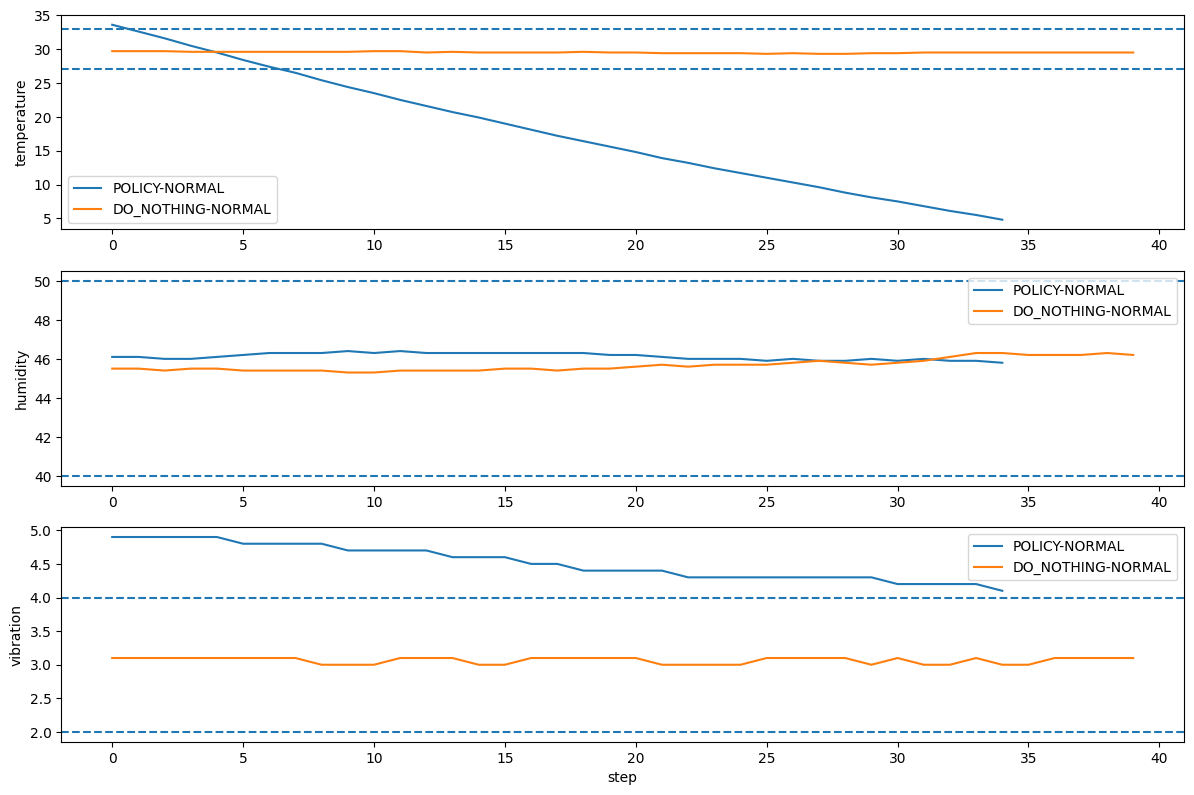

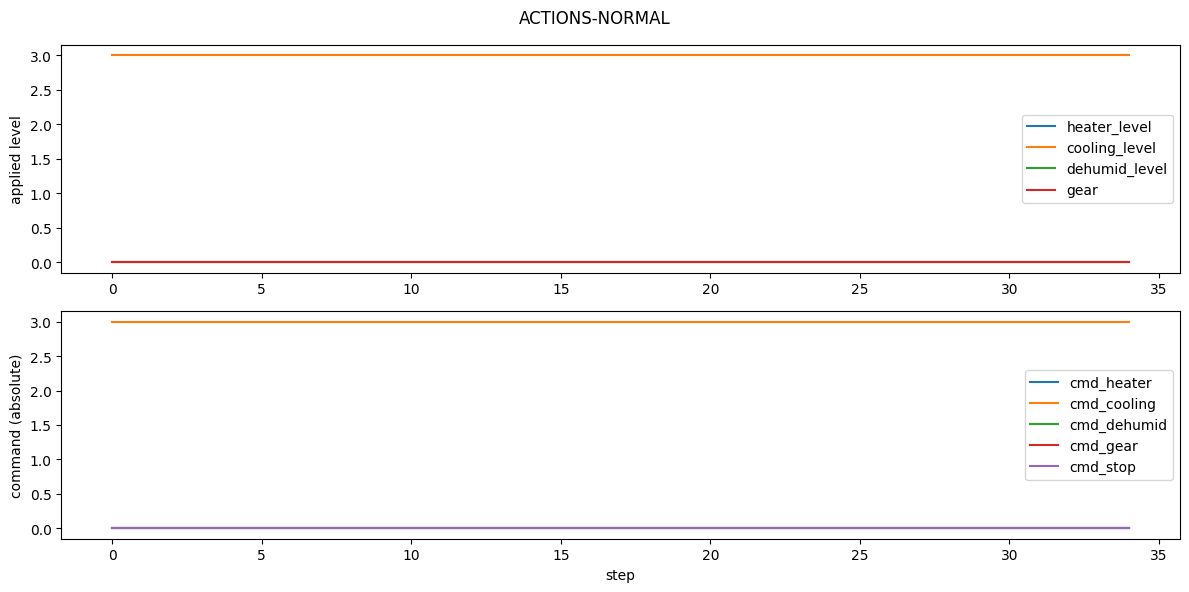


===== REPORT (refactored) =====
{
  "policy": {
    "steps": 28,
    "enter_normal_step": null,
    "total_cost": 1.0,
    "total_reward": -75378.0,
    "max_temp": 29.299999237060547,
    "max_hum": 67.4000015258789,
    "max_vib": 3.200000047683716,
    "action_activity_last": 6,
    "stop_any": 1
  },
  "do_nothing": {
    "steps": 40,
    "enter_normal_step": 0,
    "total_cost": 0.0,
    "total_reward": 35.0,
    "max_temp": 30.700000762939453,
    "max_hum": 45.900001525878906,
    "max_vib": 3.0999999046325684,
    "action_activity_last": 0,
    "stop_any": 0
  },
  "scenario": "TEMP_RUNAWAY"
}

[POLICY TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,29.299999,63.599998,3.1,0,13.6,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-1365.0,6
1,1,28.200001,63.599998,3.1,0,13.6,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-1359.0,6
2,2,27.000000,63.599998,3.1,0,13.6,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-1359.0,6
3,3,26.000000,63.700001,3.2,0,14.7,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-1479.0,6
4,4,24.900000,63.900002,3.1,0,16.0,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-1609.0,6
5,5,23.900000,64.000000,3.2,0,17.1,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-1709.0,6
6,6,22.799999,64.099998,3.2,0,18.3,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-1839.0,6
7,7,21.799999,64.400002,3.2,0,19.6,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-1969.0,6
8,8,20.799999,64.500000,3.2,0,20.7,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-2069.0,6
9,9,19.799999,64.699997,3.2,0,21.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-2189.0,6



[DO_NOTHING TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,30.600000,45.400002,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
1,1,30.500000,45.299999,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
2,2,30.600000,45.500000,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
3,3,30.600000,45.500000,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
4,4,30.600000,45.500000,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
5,5,30.600000,45.599998,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
6,6,30.700001,45.599998,3.0,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
7,7,30.700001,45.500000,3.0,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
8,8,30.700001,45.700001,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
9,9,30.600000,45.799999,3.1,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0


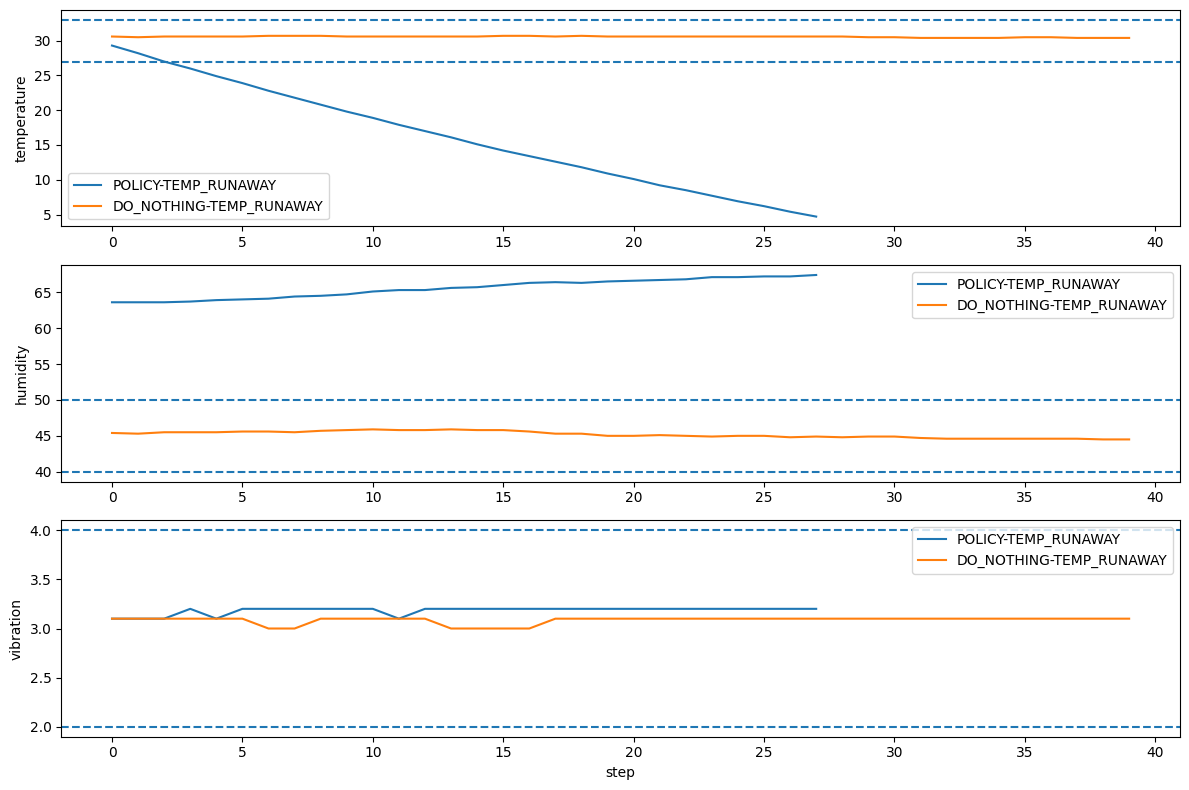

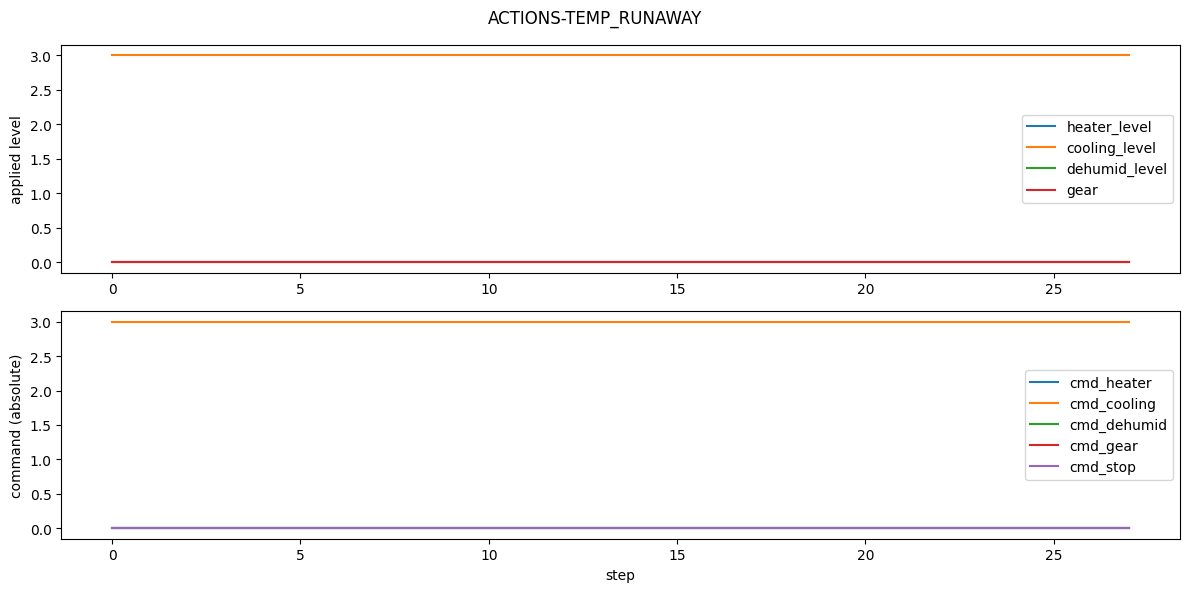


===== REPORT (refactored) =====
{
  "policy": {
    "steps": 35,
    "enter_normal_step": null,
    "total_cost": 1.0,
    "total_reward": -36831.0,
    "max_temp": 34.0,
    "max_hum": 46.20000076293945,
    "max_vib": 5.0,
    "action_activity_last": 6,
    "stop_any": 1
  },
  "do_nothing": {
    "steps": 40,
    "enter_normal_step": 0,
    "total_cost": 0.0,
    "total_reward": 35.0,
    "max_temp": 30.100000381469727,
    "max_hum": 44.79999923706055,
    "max_vib": 2.9000000953674316,
    "action_activity_last": 0,
    "stop_any": 0
  },
  "scenario": "VIB_UP"
}

[POLICY TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,34.000000,45.900002,5.0,0,2.0,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-205.0,6
1,1,32.799999,45.900002,5.0,0,1.0,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-99.0,6
2,2,31.700001,45.799999,5.0,0,1.0,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-99.0,6
3,3,30.600000,45.799999,4.9,0,0.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-99.0,6
4,4,29.600000,45.900002,4.9,0,0.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-99.0,6
5,5,28.600000,46.000000,4.8,0,0.8,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-89.0,6
6,6,27.500000,46.099998,4.8,0,0.8,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-89.0,6
7,7,26.500000,45.900002,4.8,0,1.3,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-139.0,6
8,8,25.600000,45.799999,4.7,0,2.1,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-209.0,6
9,9,24.600000,45.900002,4.7,0,3.1,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-309.0,6



[DO_NOTHING TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,30.100000,44.599998,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
1,1,30.000000,44.700001,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
2,2,30.100000,44.599998,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
3,3,30.100000,44.700001,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
4,4,30.000000,44.700001,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
5,5,30.000000,44.700001,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
6,6,29.900000,44.799999,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
7,7,29.900000,44.700001,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
8,8,29.799999,44.700001,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0
9,9,29.799999,44.599998,2.9,1,0.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,1.0,0


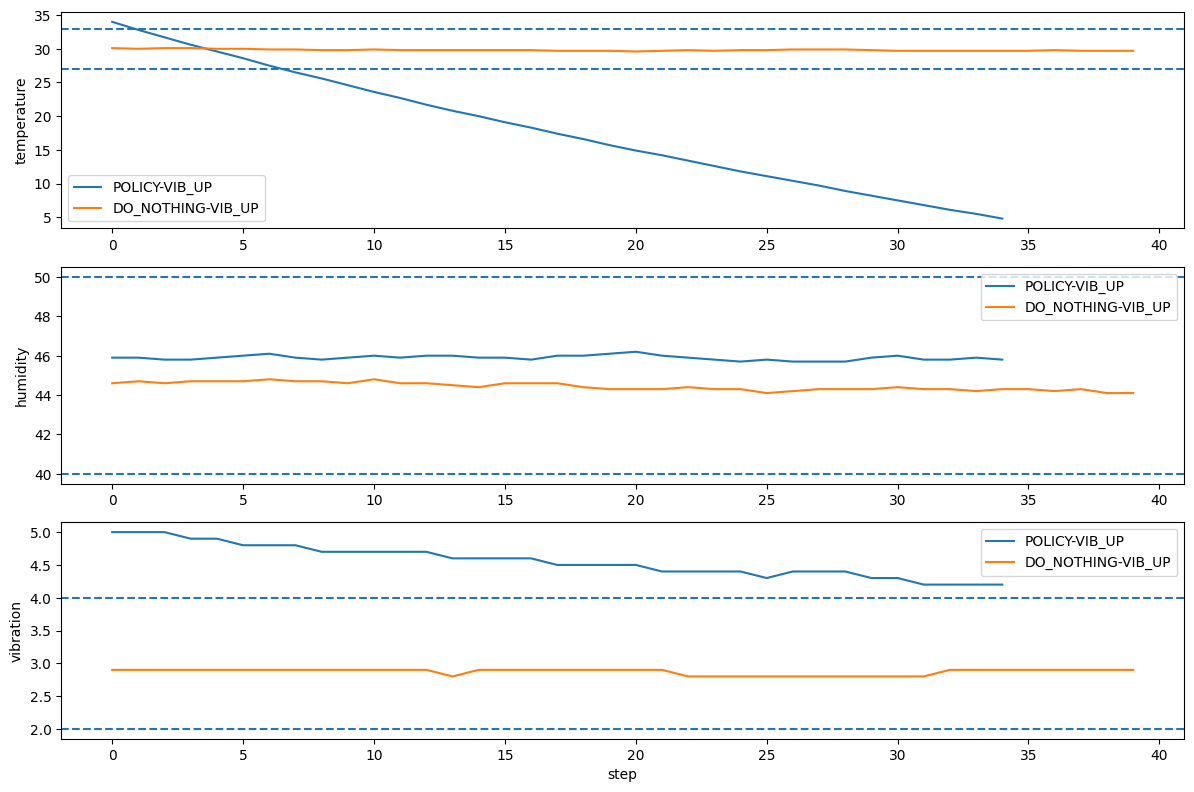

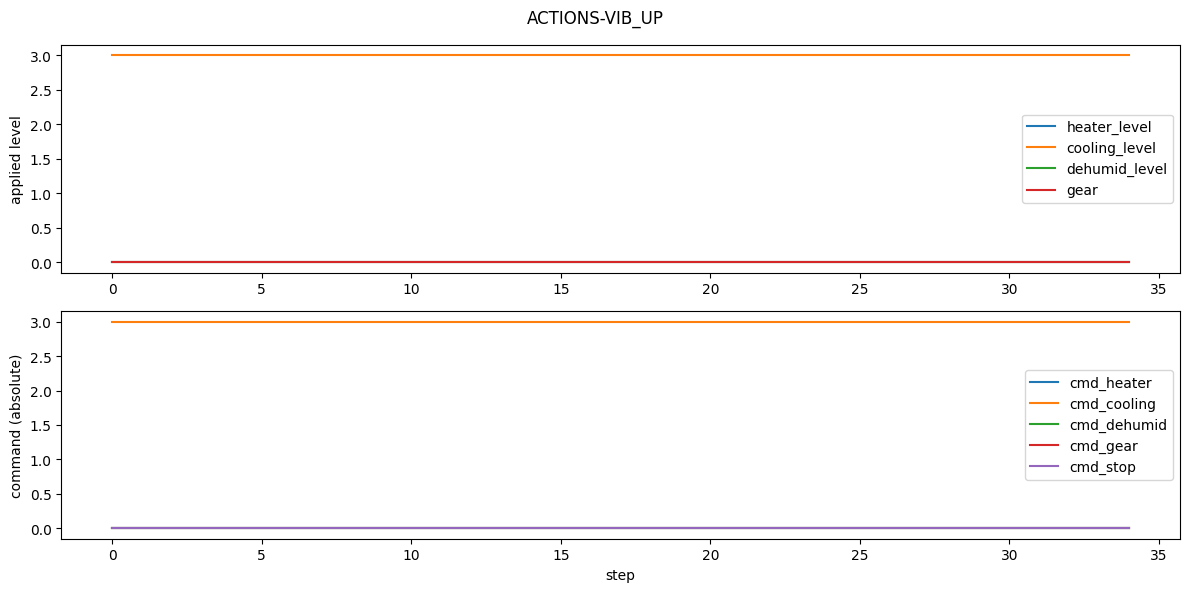


===== REPORT (refactored) =====
{
  "policy": {
    "steps": 31,
    "enter_normal_step": 0,
    "total_cost": 1.0,
    "total_reward": -36245.0,
    "max_temp": 29.299999237060547,
    "max_hum": 46.29999923706055,
    "max_vib": 3.0,
    "action_activity_last": 6,
    "stop_any": 1
  },
  "do_nothing": {
    "steps": 40,
    "enter_normal_step": null,
    "total_cost": 0.0,
    "total_reward": -64935.0,
    "max_temp": 29.5,
    "max_hum": 68.5,
    "max_vib": 3.0,
    "action_activity_last": 0,
    "stop_any": 1
  },
  "scenario": "HUM_UP"
}

[POLICY TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,29.299999,46.200001,2.8,1,0.0,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-35.0,6
1,1,28.200001,46.200001,2.8,1,0.0,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-29.0,6
2,2,27.100000,46.200001,2.8,1,0.0,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-29.0,6
3,3,26.100000,46.200001,2.7,0,0.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-89.0,6
4,4,25.100000,46.200001,2.7,0,1.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-189.0,6
5,5,24.100000,46.200001,2.7,0,2.9,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-289.0,6
6,6,23.200001,46.200001,2.7,0,3.8,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-379.0,6
7,7,22.200001,46.299999,2.8,0,4.8,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-479.0,6
8,8,21.299999,46.099998,2.7,0,5.7,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-569.0,6
9,9,20.299999,46.000000,2.7,0,6.7,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-669.0,6



[DO_NOTHING TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,29.500000,62.799999,3.0,0,12.8,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1289.0,0
1,1,29.400000,63.099998,3.0,0,13.1,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1309.0,0
2,2,29.299999,63.500000,3.0,0,13.5,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1349.0,0
3,3,29.200001,63.599998,3.0,0,13.6,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1359.0,0
4,4,29.100000,63.900002,3.0,0,13.9,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1399.0,0
5,5,29.100000,63.900002,3.0,0,13.9,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1399.0,0
6,6,29.000000,64.199997,3.0,0,14.2,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1429.0,0
7,7,28.799999,64.400002,3.0,0,14.4,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1449.0,0
8,8,28.700001,64.599998,2.9,0,14.6,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1469.0,0
9,9,28.600000,64.800003,2.9,0,14.8,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-1479.0,0


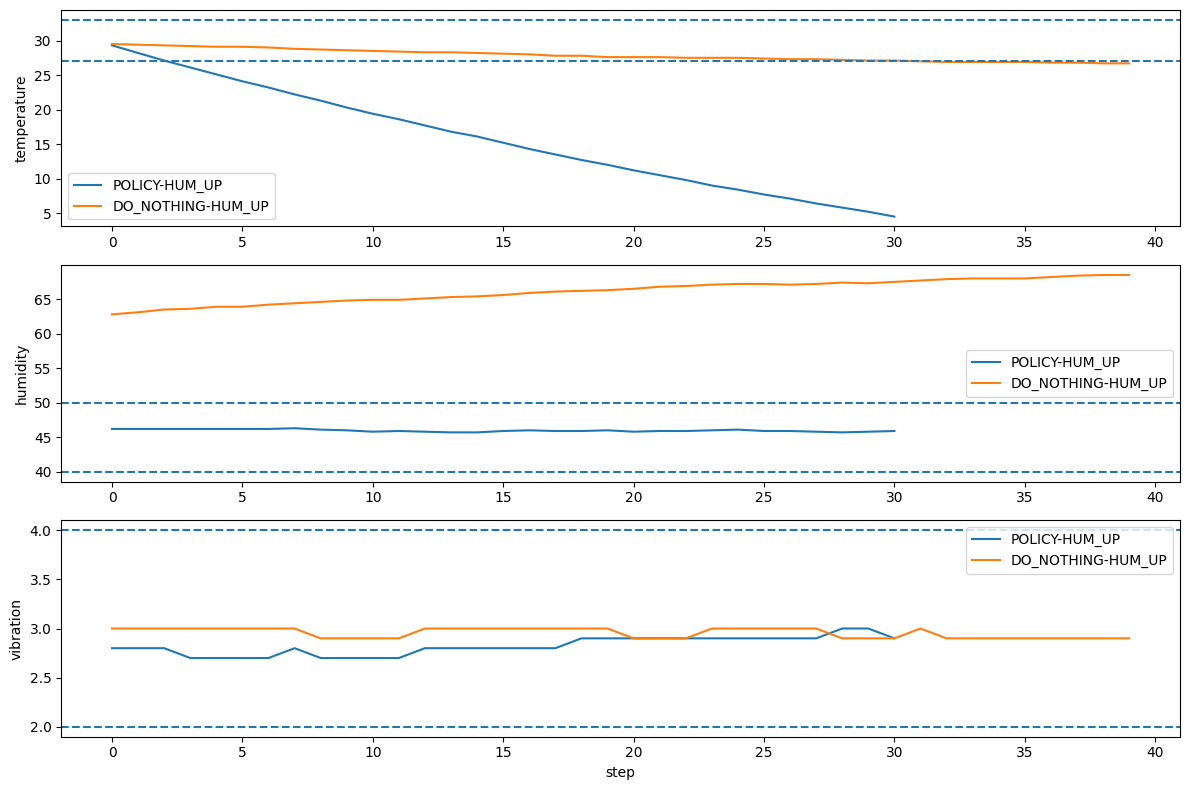

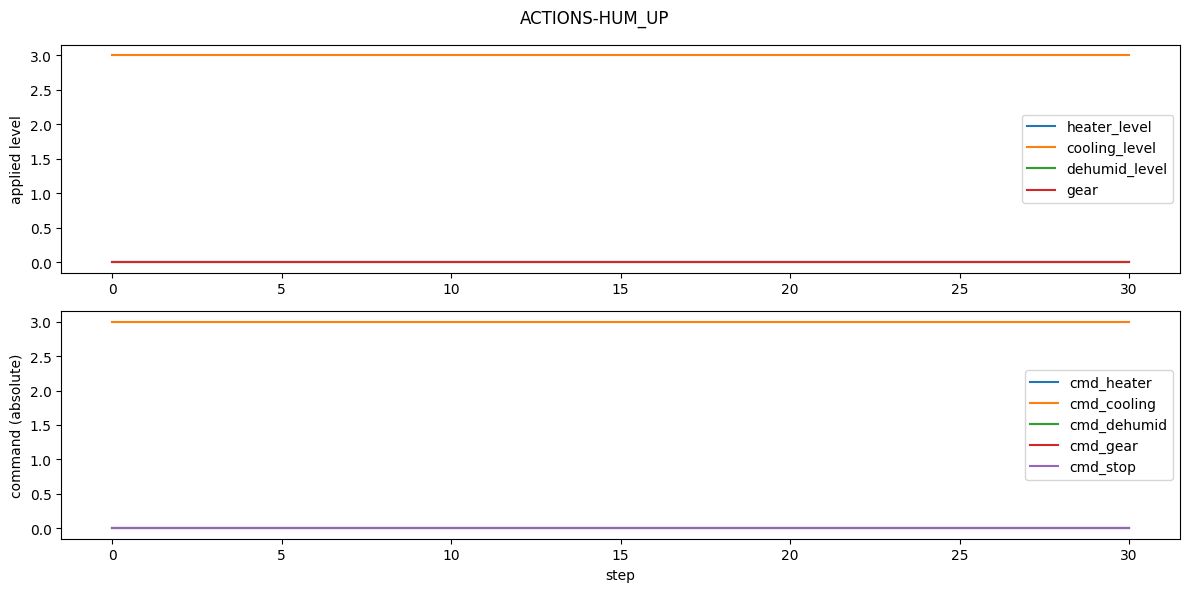


===== REPORT (refactored) =====
{
  "policy": {
    "steps": 40,
    "enter_normal_step": null,
    "total_cost": 0.0,
    "total_reward": -19150.0,
    "max_temp": 39.29999923706055,
    "max_hum": 45.29999923706055,
    "max_vib": 6.400000095367432,
    "action_activity_last": 30,
    "stop_any": 1
  },
  "do_nothing": {
    "steps": 40,
    "enter_normal_step": 37,
    "total_cost": 0.0,
    "total_reward": -5625.0,
    "max_temp": 35.400001525878906,
    "max_hum": 46.29999923706055,
    "max_vib": 4.800000190734863,
    "action_activity_last": 0,
    "stop_any": 0
  },
  "scenario": "SPEED_VIB_COUPLED"
}

[POLICY TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,39.299999,44.700001,3.3,0,6.3,0.0,3.0,0.0,5.0,0,3,0,5,0,0,0.0,0.0,-644.0,5
1,1,38.500000,44.900002,3.5,0,5.5,0.0,3.0,0.0,5.0,0,3,0,5,0,0,0.0,0.0,-549.0,5
2,2,37.799999,45.000000,3.6,0,4.8,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-494.0,10
3,3,37.000000,45.099998,3.7,0,4.0,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-399.0,10
4,4,36.299999,44.900002,3.9,0,3.3,0.0,3.0,0.0,5.0,0,3,0,5,0,0,0.0,0.0,-344.0,15
5,5,35.599998,45.000000,4.1,0,2.7,0.0,3.0,0.0,5.0,0,3,0,5,0,0,0.0,0.0,-279.0,15
6,6,34.900002,44.799999,4.2,0,2.1,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-214.0,20
7,7,34.200001,44.700001,4.2,0,1.4,0.0,3.0,0.0,0.0,0,3,0,0,0,0,0.0,0.0,-149.0,20
8,8,33.500000,44.599998,4.5,0,1.0,0.0,3.0,0.0,5.0,0,3,0,5,0,0,0.0,0.0,-104.0,25
9,9,32.799999,44.599998,4.7,0,0.7,0.0,3.0,0.0,5.0,0,3,0,5,0,0,0.0,0.0,-79.0,25



[DO_NOTHING TABLE head]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,temperature,humidity,vibration,normal,dist,heater_level,cooling_level,dehumid_level,gear,cmd_heater,cmd_cooling,cmd_dehumid,cmd_gear,cmd_stop,stop_applied,entropy,cost,reward,action_activity
0,0,35.400002,46.299999,4.8,0,3.2,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-319.0,0
1,1,35.299999,46.299999,4.8,0,3.1,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-319.0,0
2,2,35.200001,46.099998,4.8,0,3.0,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-309.0,0
3,3,35.099998,46.000000,4.7,0,2.8,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-289.0,0
4,4,35.000000,46.099998,4.7,0,2.7,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-269.0,0
5,5,35.000000,45.799999,4.6,0,2.6,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-269.0,0
6,6,34.799999,45.799999,4.6,0,2.4,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-249.0,0
7,7,34.700001,45.700001,4.6,0,2.3,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-239.0,0
8,8,34.599998,45.700001,4.6,0,2.2,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-229.0,0
9,9,34.599998,45.599998,4.6,0,2.2,0.0,0.0,0.0,3.0,0,0,0,3,0,0,0.0,0.0,-229.0,0


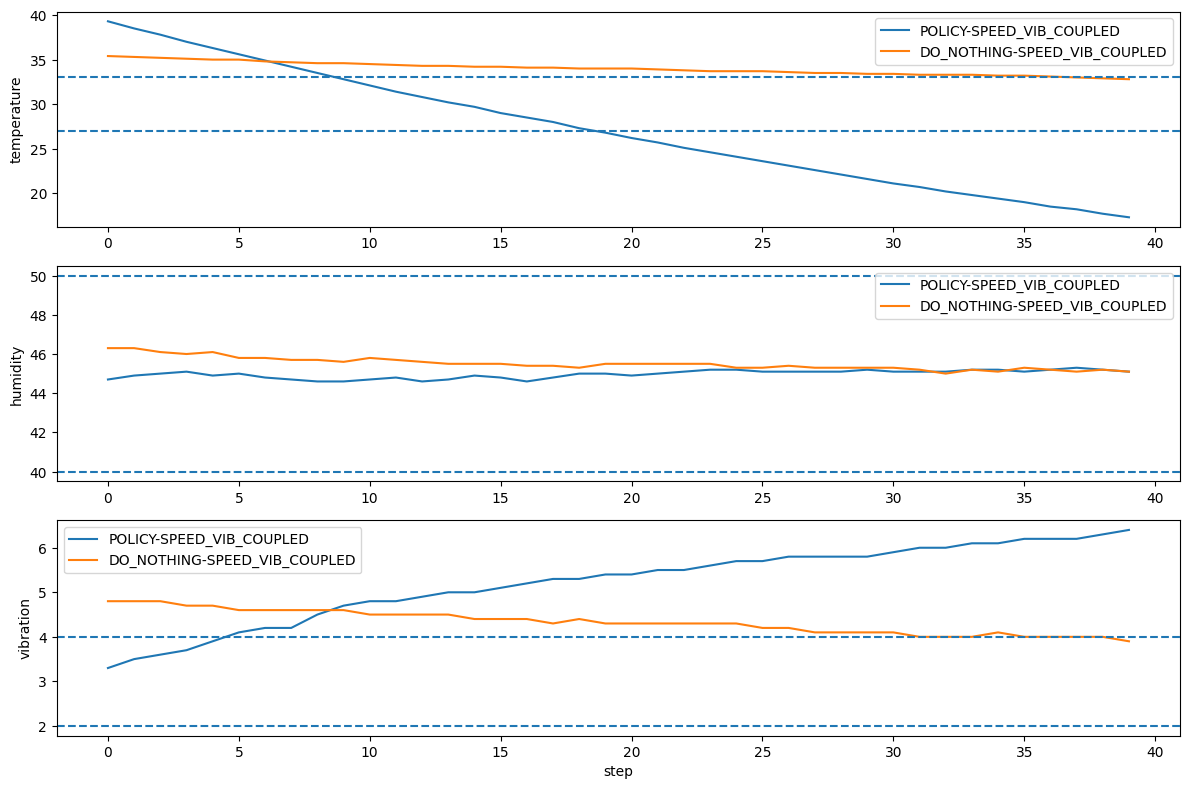

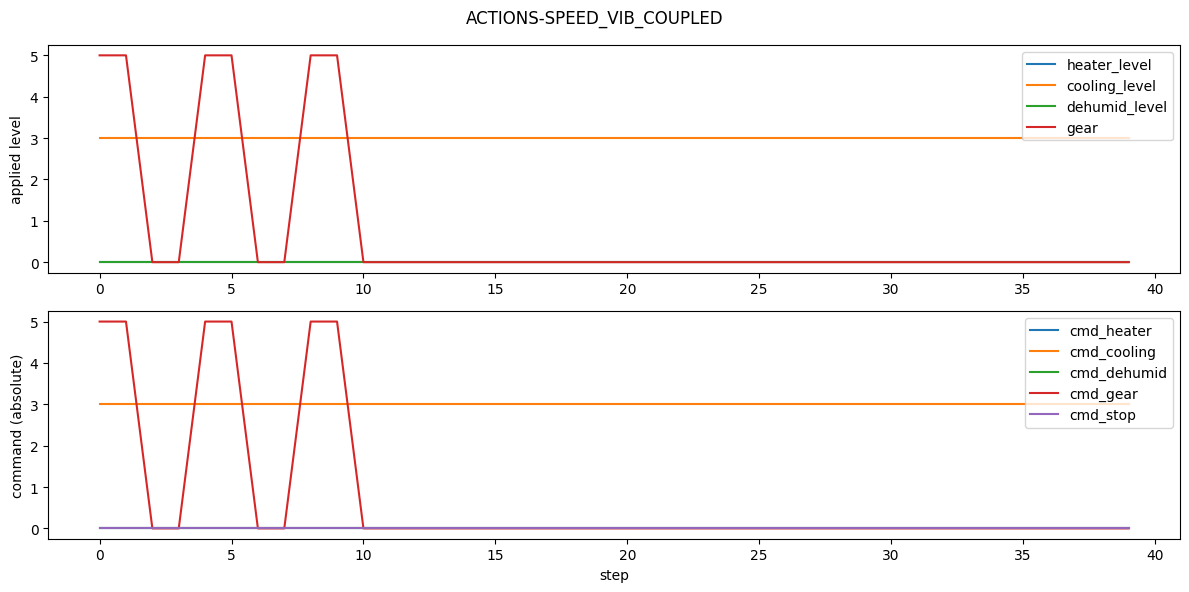

In [ ]:
# 4) Evaluate: POLICY vs DO_NOTHING
cols = [
    "step","temperature","humidity","vibration","normal","dist",
    "heater_level","cooling_level","dehumid_level","gear",
    "cmd_heater","cmd_cooling","cmd_dehumid","cmd_gear","cmd_stop",
    "stop_applied",
    "entropy",
    "cost","reward","action_activity"
]

for sc in SCENARIOS:
    env.scenario = sc
    df_pol = rollout_eval(env, policy=policy, horizon=240, do_nothing=False)
    df_non = rollout_eval(env, policy=None,   horizon=240, do_nothing=True)

    rep = {"policy": summarize(df_pol), "do_nothing": summarize(df_non), "scenario": sc}
    print("\n===== REPORT (refactored) =====")
    print(json.dumps(rep, indent=2))

    print("\n[POLICY TABLE head]")
    display(df_pol[cols].head(25))
    print("\n[DO_NOTHING TABLE head]")
    display(df_non[cols].head(25))

    plot_compare(df_pol, df_non, title1=f"POLICY-{sc}", title2=f"DO_NOTHING-{sc}")
    plot_actions(df_pol, title=f"ACTIONS-{sc}")

In [ ]:
df_pol.tail(20)[["step","cmd_stop","stop_applied","cost","normal","dist","forced_stop_reason"]]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,cmd_stop,stop_applied,cost,normal,dist,forced_stop_reason
34,34,0,0,0.0,0,1.408034,None
35,35,0,0,0.0,0,1.450076,None
36,36,0,0,0.0,0,1.526472,None
37,37,0,0,0.0,0,1.608432,None
38,38,0,0,0.0,0,1.672265,None
39,39,0,0,0.0,0,1.721649,None
40,40,0,0,0.0,0,1.811245,None
41,41,0,0,0.0,0,1.854709,None
42,42,0,0,0.0,0,1.908975,None
43,43,0,0,0.0,0,1.959507,None


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("RESET controls", env.plant.heater, env.plant.cooling, env.plant.dehumid, env.plant.gear)

RESET controls 0 0 0 3


# 환경 v1

In [ ]:
# Colab 셀 1개로 실행 가능한 Gymnasium 환경(v1) + Hard Shield(정상 band 기준)
# - Shield: 금지된 방향 Δ를 0으로 강제(완전 금지)
# - 금지 규칙(정상 band 기준):
#   T>33 -> heater +1 금지
#   T<27 -> cooling +1 금지
#   H>50 -> dehumid -1 금지
#   H<40 -> dehumid +1 금지
#   V>4  -> gear +1 금지
#   V<2  -> gear -1 금지
#
# 호환성:
# - gymnasium이면 (obs, reward, terminated, truncated, info) / reset->(obs, info)
# - gym이면        (obs, reward, done, info)               / reset->obs

import numpy as np
from dataclasses import dataclass

USING_GYMNASIUM = True
try:
    import gymnasium as gym
    from gymnasium import spaces
except Exception:
    USING_GYMNASIUM = False
    import gym
    from gym import spaces


# -----------------------------
# Helpers
# -----------------------------
def in_band(x, lo, hi):
    return (x >= lo) and (x <= hi)

def band_excess_norm(x, lo, hi, band_width):
    # 정상 band 밖 초과량 / band폭
    if x < lo:
        return (lo - x) / band_width
    if x > hi:
        return (x - hi) / band_width
    return 0.0

def make_envelope(shape: str, length: int):
    """0..1 envelope"""
    if length <= 1:
        return np.ones((length,), dtype=np.float32)
    t = np.linspace(0, 1, length, dtype=np.float32)

    if shape == "sin":
        env = np.sin(np.pi * t)
        return np.clip(env, 0, 1).astype(np.float32)

    if shape == "plateau":
        ramp = 0.2
        env = np.ones_like(t)
        up = t < ramp
        dn = t > (1 - ramp)
        env[up] = t[up] / ramp
        env[dn] = (1 - t[dn]) / ramp
        return np.clip(env, 0, 1).astype(np.float32)

    if shape == "step":
        env = np.ones_like(t)
        env[t < 0.05] = t[t < 0.05] / 0.05
        return np.clip(env, 0, 1).astype(np.float32)

    if shape == "double":
        env = 0.6 * np.sin(np.pi * t) + 0.4 * np.sin(2 * np.pi * t)
        env = np.maximum(env, 0)
        env = env / (env.max() + 1e-6)
        return env.astype(np.float32)

    env = np.sin(np.pi * t)
    return np.clip(env, 0, 1).astype(np.float32)


# -----------------------------
# Config
# -----------------------------
@dataclass
class EnvConfig:
    # Episode
    T_max: int = 180
    recover_N: int = 10
    fail_K: int = 30

    # Normal band (복귀 판정)
    T_lo: float = 27.0
    T_hi: float = 33.0
    H_lo: float = 40.0
    H_hi: float = 50.0
    V_lo: float = 2.0
    V_hi: float = 4.0

    # Safety limits (E-stop)
    T_min: float = 5.0
    T_max_safe: float = 75.0
    H_min: float = 5.0
    H_max_safe: float = 80.0
    V_min: float = 0.5
    V_max_safe: float = 8.0

    # Base dynamics
    tau_base: float = 40.0

    # Control smoothing (20 step 적용)
    tau_ctrl: float = 20.0

    # Rate limit
    rate_limit_steps: int = 5

    # Noise (작게)
    sigma_T: float = 0.03
    sigma_H: float = 0.08
    sigma_V: float = 0.01

    # Domain randomization
    domain_randomize: bool = True
    dr_tau_base: float = 0.20
    dr_gain: float = 0.15
    dr_sigma: float = 0.20

    # Shield
    use_shield: bool = True

    # Action penalties
    effort_coef: float = 0.01
    change_coef: float = 0.02

    # Terminal rewards
    recover_bonus: float = 1.0
    success_terminal: float = 5.0
    stop_penalty: float = -1.0


# -----------------------------
# Env
# -----------------------------
class RailControlSafeEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, config: EnvConfig = EnvConfig(), seed: int = 0):
        super().__init__()
        self.cfg = config
        self.rng = np.random.default_rng(seed)

        # Actions: 4 deltas, each in {0,1,2} -> {-1,0,+1}
        self.action_space = spaces.MultiDiscrete([3, 3, 3, 3])

        # Observation: [T,H,V, gear, heater,cooling,dehumid, step_norm]
        low = np.array([0.0,   0.0,   0.0,   0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        high= np.array([100.0, 120.0, 30.0,  6.0, 3.0, 3.0, 3.0, 1.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        # band widths
        self.band_T = self.cfg.T_hi - self.cfg.T_lo  # 6
        self.band_H = self.cfg.H_hi - self.cfg.H_lo  # 10
        self.band_V = self.cfg.V_hi - self.cfg.V_lo  # 2

        # band center targets
        self.mu_T = (self.cfg.T_lo + self.cfg.T_hi) / 2.0
        self.mu_H = (self.cfg.H_lo + self.cfg.H_hi) / 2.0
        self.mu_V = (self.cfg.V_lo + self.cfg.V_hi) / 2.0

        self.reset(seed=seed)

    # -----------------------------
    # Shield (Hard) : 정상 band 기준
    # -----------------------------
    def _shield_deltas(self, d_heater, d_cooling, d_dehumid, d_gear):
        if not self.cfg.use_shield:
            return d_heater, d_cooling, d_dehumid, d_gear, False, [0, 0, 0, 0]

        mask = [0, 0, 0, 0]  # [heater, cooling, dehumid, gear]
        applied = False

        # T>33 => heater +1 금지
        if (self.T > self.cfg.T_hi) and (d_heater > 0):
            d_heater = 0
            mask[0] = 1
            applied = True

        # T<27 => cooling +1 금지
        if (self.T < self.cfg.T_lo) and (d_cooling > 0):
            d_cooling = 0
            mask[1] = 1
            applied = True

        # H>50 => dehumid -1 금지 (제습 낮추지 못함)
        if (self.H > self.cfg.H_hi) and (d_dehumid < 0):
            d_dehumid = 0
            mask[2] = 1
            applied = True

        # H<40 => dehumid +1 금지 (더 말리지 못함)
        if (self.H < self.cfg.H_lo) and (d_dehumid > 0):
            d_dehumid = 0
            mask[2] = 1
            applied = True

        # V>4 => gear +1 금지
        if (self.V > self.cfg.V_hi) and (d_gear > 0):
            d_gear = 0
            mask[3] = 1
            applied = True

        # V<2 => gear -1 금지
        if (self.V < self.cfg.V_lo) and (d_gear < 0):
            d_gear = 0
            mask[3] = 1
            applied = True

        return d_heater, d_cooling, d_dehumid, d_gear, applied, mask

    # -----------------------------
    # Anomaly sampler (v1)
    # -----------------------------
    def _sample_anomaly(self):
        """
        (전체 phase 이상 데이터.py 설계를 따라가는 목적의 v1 근사) (GPT추론)
        """
        dur = int(self.rng.integers(50, self.cfg.T_max + 1))
        severity = float(self.rng.uniform(0.25, 0.95))
        shape = self.rng.choice(["sin", "plateau", "step", "double"], p=[0.35, 0.35, 0.15, 0.15])
        env = make_envelope(shape, dur)

        label = self.rng.choice(
            ["TEMP_RUNAWAY", "HUM_UP_TEMP_DOWN", "VIB_RISE_TEMP_LAG", "VIB_SPIKE_REPEAT"],
            p=[0.25, 0.25, 0.25, 0.25]
        )

        dT = np.zeros((dur,), dtype=np.float32)
        dH = np.zeros((dur,), dtype=np.float32)
        dV = np.zeros((dur,), dtype=np.float32)

        if label == "TEMP_RUNAWAY":
            ampT = float(self.rng.uniform(8.0, 25.0)) * severity
            dT = (ampT * env).astype(np.float32)

        elif label == "HUM_UP_TEMP_DOWN":
            ampH = float(self.rng.uniform(15.0, 40.0)) * severity
            ampT = float(self.rng.uniform(5.0, 15.0)) * severity
            dH = (ampH * env).astype(np.float32)
            dT = (-ampT * env).astype(np.float32)

        elif label == "VIB_RISE_TEMP_LAG":
            ampV = float(self.rng.uniform(1.5, 4.5)) * severity
            ampT = float(self.rng.uniform(4.0, 12.0)) * severity
            dV = (ampV * env).astype(np.float32)

            lag = int(self.rng.integers(5, 25))
            env_lag = np.zeros_like(env)
            if lag < dur:
                env_lag[lag:] = env[:dur - lag]
            dT = (ampT * env_lag).astype(np.float32)

        elif label == "VIB_SPIKE_REPEAT":
            spike_amp = float(self.rng.uniform(1.5, 6.0)) * severity
            width = int(self.rng.integers(1, 4))
            n_spikes = int(self.rng.integers(max(2, dur // 40), max(3, dur // 15)))
            for _ in range(n_spikes):
                pos = int(self.rng.integers(0, max(1, dur - width)))
                dV[pos:pos + width] += spike_amp
            dV = np.clip(dV, 0.0, spike_amp * 2.0).astype(np.float32)

        return label, dT, dH, dV

    # -----------------------------
    # Control model
    # -----------------------------
    def _control_targets(self):
        """
        레벨 -> 누적 변화량(정상 band 폭 대비 %) -> step당 rate
        """
        level = self.levels
        g = self.gain_scale

        # heater/cooling: 20/40/60% of band_T
        heater_tot = [0.0, 0.20 * self.band_T, 0.40 * self.band_T, 0.60 * self.band_T][level["heater"]] * g["heater"]
        cool_tot   = [0.0, 0.20 * self.band_T, 0.40 * self.band_T, 0.60 * self.band_T][level["cooling"]] * g["cooling"]

        # dehumid: 10/20/30% of band_H
        dehum_tot  = [0.0, 0.10 * self.band_H, 0.20 * self.band_H, 0.30 * self.band_H][level["dehumid"]] * g["dehumid"]

        rate_T = (heater_tot - cool_tot) / self.tau_ctrl
        rate_H = (-dehum_tot) / self.tau_ctrl

        gear = int(level["gear"])
        # gear=0은 사용자 정의가 없어서 gear=1로 취급 (GPT추론)
        gear_map = {
            0: (-0.60, -0.20),
            1: (-0.60, -0.20),
            2: (-0.30, -0.10),
            3: ( 0.00,  0.00),
            4: (+0.30, +0.10),
            5: (+0.60, +0.20),
            6: (+0.90, +0.30),
        }
        vib_pct, temp_pct = gear_map.get(gear, (0.0, 0.0))

        vib_tot  = (vib_pct  * self.band_V) * g["gear_vib"]
        temp_tot = (temp_pct * self.band_T) * g["gear_temp"]

        rate_V = vib_tot / self.tau_ctrl
        rate_T += temp_tot / self.tau_ctrl

        return rate_T, rate_H, rate_V

    # -----------------------------
    # Reward/termination helpers
    # -----------------------------
    def _dist(self, T, H, V):
        eT = band_excess_norm(T, self.cfg.T_lo, self.cfg.T_hi, self.band_T)
        eH = band_excess_norm(H, self.cfg.H_lo, self.cfg.H_hi, self.band_H)
        eV = band_excess_norm(V, self.cfg.V_lo, self.cfg.V_hi, self.band_V)
        return float(eT + eH + eV)

    def _is_normal(self, T, H, V):
        return in_band(T, self.cfg.T_lo, self.cfg.T_hi) and in_band(H, self.cfg.H_lo, self.cfg.H_hi) and in_band(V, self.cfg.V_lo, self.cfg.V_hi)

    def _is_esafe(self, T, H, V):
        return (T < self.cfg.T_min) or (T > self.cfg.T_max_safe) or (H < self.cfg.H_min) or (H > self.cfg.H_max_safe) or (V < self.cfg.V_min) or (V > self.cfg.V_max_safe)

    # -----------------------------
    # Gym API
    # -----------------------------
    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        # Domain randomization
        if self.cfg.domain_randomize:
            def jitter(x, frac):
                return x * (1.0 + self.rng.uniform(-frac, +frac))

            self.tau_base = float(jitter(self.cfg.tau_base, self.cfg.dr_tau_base))
            self.tau_ctrl = float(jitter(self.cfg.tau_ctrl, 0.10))

            self.sig_T = float(jitter(self.cfg.sigma_T, self.cfg.dr_sigma))
            self.sig_H = float(jitter(self.cfg.sigma_H, self.cfg.dr_sigma))
            self.sig_V = float(jitter(self.cfg.sigma_V, self.cfg.dr_sigma))

            self.gain_scale = {
                "heater": float(jitter(1.0, self.cfg.dr_gain)),
                "cooling": float(jitter(1.0, self.cfg.dr_gain)),
                "dehumid": float(jitter(1.0, self.cfg.dr_gain)),
                "gear_vib": float(jitter(1.0, self.cfg.dr_gain)),
                "gear_temp": float(jitter(1.0, self.cfg.dr_gain)),
            }
        else:
            self.tau_base = float(self.cfg.tau_base)
            self.tau_ctrl = float(self.cfg.tau_ctrl)
            self.sig_T, self.sig_H, self.sig_V = self.cfg.sigma_T, self.cfg.sigma_H, self.cfg.sigma_V
            self.gain_scale = {"heater": 1.0, "cooling": 1.0, "dehumid": 1.0, "gear_vib": 1.0, "gear_temp": 1.0}

        # Initial sensor state near band center
        self.T = float(self.mu_T + self.rng.normal(0, 0.2))
        self.H = float(self.mu_H + self.rng.normal(0, 0.8))
        self.V = float(self.mu_V + self.rng.normal(0, 0.05))

        # Controls
        self.levels = {"heater": 0, "cooling": 0, "dehumid": 0, "gear": 3}
        self.last_change = {"heater": -999, "cooling": -999, "dehumid": -999, "gear": -999}

        # Smoothed control rates
        self.ctrl_rate_T = 0.0
        self.ctrl_rate_H = 0.0
        self.ctrl_rate_V = 0.0

        # Episode step
        self.k = 0

        # Counters
        self.out_counter = 0
        self.recover_counter = 0
        self._recover_bonus_given = False

        # Anomaly schedule
        self.anom_label, dT, dH, dV = self._sample_anomaly()
        max_onset = max(0, self.cfg.T_max - len(dT))
        self.anom_onset = int(self.rng.integers(0, max_onset + 1))
        self.dT, self.dH, self.dV = dT, dH, dV
        self.prev_off_T = 0.0
        self.prev_off_H = 0.0
        self.prev_off_V = 0.0

        obs = self._get_obs()
        info = {"anom_label": self.anom_label, "anom_onset": int(self.anom_onset), "anom_dur": int(len(self.dT))}

        if USING_GYMNASIUM:
            return obs, info
        return obs

    def _get_obs(self):
        step_norm = 0.0 if self.cfg.T_max <= 1 else (self.k / (self.cfg.T_max - 1))
        return np.array([
            self.T, self.H, self.V,
            float(self.levels["gear"]),
            float(self.levels["heater"]),
            float(self.levels["cooling"]),
            float(self.levels["dehumid"]),
            float(step_norm),
        ], dtype=np.float32)

    def step(self, action):
        action = np.asarray(action, dtype=np.int64)
        assert action.shape == (4,)

        # prev dist for progress reward
        dist_prev = self._dist(self.T, self.H, self.V)

        # map {0,1,2} -> {-1,0,+1}
        deltas = action - 1
        d_heater, d_cooling, d_dehumid, d_gear = [int(x) for x in deltas]

        # ---- Shield BEFORE rate limit/apply ----
        d_heater, d_cooling, d_dehumid, d_gear, shield_applied, shield_mask = self._shield_deltas(
            d_heater, d_cooling, d_dehumid, d_gear
        )

        # Rate limit + apply
        def apply_delta(key, d, lo, hi):
            if d == 0:
                return False
            if (self.k - self.last_change[key]) < self.cfg.rate_limit_steps:
                return False
            newv = int(np.clip(self.levels[key] + d, lo, hi))
            if newv != self.levels[key]:
                self.levels[key] = newv
                self.last_change[key] = self.k
                return True
            return False

        applied_flags = {
            "heater": apply_delta("heater",  d_heater,  0, 3),
            "cooling": apply_delta("cooling", d_cooling, 0, 3),
            "dehumid": apply_delta("dehumid", d_dehumid, 0, 3),
            "gear": apply_delta("gear", d_gear, 0, 6),
        }

        # Control targets
        tgt_T, tgt_H, tgt_V = self._control_targets()

        # Smooth control rate to targets (first-order lag)
        alpha = 1.0 / self.tau_ctrl
        self.ctrl_rate_T = (1 - alpha) * self.ctrl_rate_T + alpha * tgt_T
        self.ctrl_rate_H = (1 - alpha) * self.ctrl_rate_H + alpha * tgt_H
        self.ctrl_rate_V = (1 - alpha) * self.ctrl_rate_V + alpha * tgt_V

        # Base drift to band center
        base_alpha = 1.0 / self.tau_base
        base_dT = base_alpha * (self.mu_T - self.T)
        base_dH = base_alpha * (self.mu_H - self.H)
        base_dV = base_alpha * (self.mu_V - self.V)

        # Anomaly incremental offsets
        off_T = off_H = off_V = 0.0
        idx = self.k - self.anom_onset
        if 0 <= idx < len(self.dT):
            off_T = float(self.dT[idx])
            off_H = float(self.dH[idx])
            off_V = float(self.dV[idx])

        inc_off_T = off_T - self.prev_off_T
        inc_off_H = off_H - self.prev_off_H
        inc_off_V = off_V - self.prev_off_V
        self.prev_off_T, self.prev_off_H, self.prev_off_V = off_T, off_H, off_V

        # Noise
        nT = float(self.rng.normal(0, self.sig_T))
        nH = float(self.rng.normal(0, self.sig_H))
        nV = float(self.rng.normal(0, self.sig_V))

        # Update sensors
        self.T += base_dT + self.ctrl_rate_T + inc_off_T + nT
        self.H += base_dH + self.ctrl_rate_H + inc_off_H + nH
        self.V += base_dV + self.ctrl_rate_V + inc_off_V + nV

        # broad physical clamp
        self.T = float(np.clip(self.T, -20.0, 120.0))
        self.H = float(np.clip(self.H, 0.0, 120.0))
        self.V = float(np.clip(self.V, 0.0, 40.0))

        # Counters (out_counter: 정상 band 밖 연속)
        normal = self._is_normal(self.T, self.H, self.V)
        if normal:
            self.out_counter = 0
            self.recover_counter += 1
        else:
            self.out_counter += 1
            self.recover_counter = 0

        # Termination
        e_stop = self._is_esafe(self.T, self.H, self.V)
        fail_stop = (self.out_counter >= self.cfg.fail_K)
        success = (self.recover_counter >= self.cfg.recover_N)
        time_up = (self.k >= self.cfg.T_max - 1)

        terminated = bool(e_stop or fail_stop or success)
        truncated = bool((not terminated) and time_up)

        # Reward
        dist_now = self._dist(self.T, self.H, self.V)
        r_progress = float(dist_prev - dist_now)

        effort = self.levels["heater"] + self.levels["cooling"] + self.levels["dehumid"]
        r_effort = -self.cfg.effort_coef * float(effort)

        # change penalty based on (shield 적용 후) 델타 크기
        r_change = -self.cfg.change_coef * float(abs(d_heater) + abs(d_cooling) + abs(d_dehumid) + abs(d_gear))

        reward = float(r_progress + r_effort + r_change)

        # one-time bonus when first entering normal band
        if normal and (not self._recover_bonus_given):
            reward += float(self.cfg.recover_bonus)
            self._recover_bonus_given = True

        if success:
            reward += float(self.cfg.success_terminal)
        if e_stop or fail_stop:
            reward += float(self.cfg.stop_penalty)

        # Cost (CMDP): E-stop만 비용 1
        cost = 1.0 if e_stop else 0.0

        info = {
            "cost": float(cost),
            "shield_applied": bool(shield_applied),
            "shield_mask": list(map(int, shield_mask)),
            "applied_flags": dict(applied_flags),
            "out_counter": int(self.out_counter),
            "recover_counter": int(self.recover_counter),
            "e_stop": bool(e_stop),
            "fail_stop": bool(fail_stop),
            "success": bool(success),
            "anom_label": self.anom_label,
            "anom_onset": int(self.anom_onset),
            "anom_dur": int(len(self.dT)),
            "levels": dict(self.levels),
        }

        self.k += 1
        obs = self._get_obs()

        if USING_GYMNASIUM:
            return obs, reward, terminated, truncated, info
        done = bool(terminated or truncated)
        return obs, reward, done, info


# -----------------------------
# Quick sanity test
# -----------------------------
if __name__ == "__main__":
    cfg = EnvConfig(
        T_max=180,
        recover_N=10,
        fail_K=30,
        domain_randomize=True,
        use_shield=True,
        stop_penalty=-1.0,
    )

    env = RailControlSafeEnv(cfg, seed=42)

    if USING_GYMNASIUM:
        obs, info = env.reset()
        print("reset info:", info)
    else:
        obs = env.reset()
        print("reset done (gym mode)")

    total_r = 0.0
    total_c = 0.0
    shield_hits = 0

    for _ in range(cfg.T_max):
        a = env.action_space.sample()
        if USING_GYMNASIUM:
            obs, r, term, trunc, info = env.step(a)
            done = term or trunc
        else:
            obs, r, done, info = env.step(a)

        total_r += r
        total_c += info.get("cost", 0.0)
        shield_hits += int(info.get("shield_applied", False))

        if done:
            print("done:", {
                "e_stop": info.get("e_stop"),
                "fail_stop": info.get("fail_stop"),
                "success": info.get("success"),
                "out_counter": info.get("out_counter"),
                "recover_counter": info.get("recover_counter"),
                "anom_label": info.get("anom_label"),
                "shield_hits": shield_hits,
            })
            break

    print("total_reward:", total_r, "total_cost:", total_c, "shield_hits:", shield_hits)

reset info: {'anom_label': np.str_('TEMP_RUNAWAY'), 'anom_onset': 33, 'anom_dur': 132}
done: {'e_stop': False, 'fail_stop': False, 'success': True, 'out_counter': 0, 'recover_counter': 10, 'anom_label': np.str_('TEMP_RUNAWAY'), 'shield_hits': 0}
total_reward: 5.16 total_cost: 0.0 shield_hits: 0


# 환경 v2

In [ ]:
import os, sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client"
)

# --- gymnasium ---
try:
    import gymnasium as gym
    from gymnasium import spaces
except Exception:
    raise RuntimeError("gymnasium 필요: `pip install gymnasium` 후 재실행")

# --- (optional) stable-baselines3 ---
# !pip -q install stable-baselines3

import importlib.util
import joblib


# ===============================
# Paths (Colab 업로드 파일)
# ===============================
IFRF_PY_PATH = "/content/IFRF.py"
UNIFIED_PKL  = "/content/unified_model (4).pkl"


# ===============================
# Normal/Safe bands (v1 md 기반)  (출처: 업로드 md)
# ===============================
NORMAL_BAND = {
    "temperature": (27.0, 33.0),
    "humidity":    (40.0, 50.0),
    "vibration":   (2.0,  4.0),
}
SAFE_LIMIT = {
    "temperature": (5.0,  75.0),
    "humidity":    (5.0,  80.0),
    "vibration":   (0.5,  8.0),
}

def in_band(x, lo, hi):
    return (x >= lo) and (x <= hi)

def band_distance(x, lo, hi):
    if x < lo: return lo - x
    if x > hi: return x - hi
    return 0.0

def entropy_from_proba(p):
    p = np.clip(p, 1e-12, 1.0)
    p = p / p.sum()
    return float(-(p * np.log(p)).sum())


# ===============================
# UnifiedModel loader
#  - IFRF.py의 UnifiedModel/UnifiedConfig에 의존 (출처: IFRF.py, pkl)
# ===============================
def load_unified_model(pkl_path: str, ifrf_py_path: str):
    spec = importlib.util.spec_from_file_location("ifrf_module", ifrf_py_path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules["ifrf_module"] = mod
    spec.loader.exec_module(mod)

    import __main__
    __main__.UnifiedModel = mod.UnifiedModel
    __main__.UnifiedConfig = mod.UnifiedConfig

    # pickle 호환 alias (numpy._core) (GPT추론)
    import numpy.core as npcore
    sys.modules.setdefault("numpy._core", npcore)

    return joblib.load(pkl_path)


class UnifiedWrapper:
    """
    unified.predict_raw(df_raw) 실행을 위해 최근 win_size raw 버퍼 유지.
    """
    def __init__(self, unified):
        self.unified = unified
        self.win = int(getattr(unified.cfg, "win_size", 10))
        self.id_col = getattr(unified.cfg, "id_col", "session_id")
        self.t_col  = getattr(unified.cfg, "time_col", "t")
        self.sid = 1
        self.step_t = 0
        self.buffer = []
        self.is_warmup = True
        self.last_len = 0

        # classes_ 추출
        self.classes = []
        try:
            self.classes = list(unified.classifier.get("classes_", []))
        except Exception:
            self.classes = []
        self.n_cls = len(self.classes)

    def reset(self):
        self.step_t = 0
        self.buffer = []
        self.is_warmup = True
        self.last_len = 0

    def push_and_predict(self, temperature: float, humidity: float, vibration: float):
        # 버퍼 누적
        self.buffer.append({
            self.id_col: self.sid,
            self.t_col: float(self.step_t),
            "temperature": float(temperature),
            "humidity": float(humidity),
            "vibration": float(vibration),
        })
        # [ADD] warmup 상태 갱신 (필수)
        self.last_len = len(self.buffer)
        self.is_warmup = (self.last_len < self.win)
        self.step_t += 1 # Increment step_t for the next call

        # warm-up: 윈도우 길이 미만이면 균등확률/최대엔트로피로 처리
        if len(self.buffer) < self.win:
            p = np.ones(self.n_cls, dtype=np.float32) / max(self.n_cls, 1)
            ent = float(entropy_from_proba(p)) if self.n_cls > 0 else 0.0
            top_label = self.classes[0] if (self.n_cls > 0 and len(self.classes) > 0) else None
            top_proba = float(p[0]) if self.n_cls > 0 else None
            return p, ent, top_label, top_proba

        # 최근 win_size만 사용
        df_raw = pd.DataFrame(list(self.buffer)[-self.win:])

        # unified_model 호출 (네 기존 코드에 맞춰 유지)
        out = self.unified.predict_raw(df_raw)  # <-- 네 코드에서 쓰던 방식 유지

        # out에서 확률 벡터 추출 (너 코드에 맞게 조정 필요할 수 있음) (GPT추론)
        # 보통 out["proba"] 또는 out["proba_vec"] 같은 형태
        if isinstance(out, dict):
            if "proba" in out:
                p = np.array(out["proba"], dtype=np.float32)
            elif "proba_vec" in out:
                p = np.array(out["proba_vec"], dtype=np.float32)
            else:
                # fallback: proba_* 컬럼들
                proba_cols = [c for c in out.keys() if str(c).startswith("proba_")]
                p = np.array([out[c] for c in proba_cols], dtype=np.float32)
        else:
            # out이 DataFrame/Series일 수도 있으니 fallback (GPT추론)
            try:
                proba_cols = [c for c in out.columns if str(c).startswith("proba_")]
                p = out[proba_cols].iloc[-1].to_numpy(dtype=np.float32)
            except Exception:
                raise ValueError("unified predict_raw 출력에서 확률 벡터를 추출하지 못했습니다. (GPT추론)")

        # 안전장치: 정규화
        if p.ndim != 1 or len(p) == 0:
            raise ValueError("proba vector shape invalid (GPT추론)")
        psum = float(p.sum())
        if psum <= 0:
            p = np.ones_like(p) / len(p)
        else:
            p = p / psum

        ent = float(entropy_from_proba(p))

        top_i = int(np.argmax(p))
        top_label = self.classes[top_i] if (top_i < len(self.classes)) else str(top_i)
        top_proba = float(p[top_i])

        return p, ent, top_label, top_proba


# ===============================
# SimplePlant v1.1
#  - (A) forced anomaly init
#  - (B) stronger disturbance
# ===============================
class SimplePlantV11:
    """
    상태: temp, hum, vib, gear(0~6)
    제어: heater(0~3), cooling(0~3), dehumid(0~3), stop
    """
    def __init__(self, rng: np.random.Generator, disturbance_scale=1.0):
        self.rng = rng
        self.disturbance_scale = float(disturbance_scale)
        self.reset(scenario="TEMP_RUNAWAY")

    def reset(self, scenario="TEMP_RUNAWAY", severity=1.0):
        """
        scenario: TEMP_RUNAWAY / HUM_UP / VIB_UP / SPEED_VIB_COUPLED
        (A) 초기 상태를 정상 밖에서 시작하도록 강제
        """
        self.t = 0
        self.stop = 0

        self.heater = 0
        self.cooling = 0
        self.dehumid = 0
        self.gear = 3  # 중간~약간 높은 상태로 시작

        self.scenario = str(scenario)
        self.severity = float(severity)

        # --- forced anomaly init (정상 밖에서 시작) ---
        if self.scenario == "NORMAL":
            self.temp = float(self.rng.normal(30.0, 0.4))
            self.hum  = float(self.rng.normal(45.0, 0.8))
            self.vib  = float(self.rng.normal(3.0, 0.2))
            self.gear = 3  # 기본 기어 3으로 시작 (요청 반영)
        elif self.scenario == "TEMP_RUNAWAY":
            self.temp = float(self.rng.normal(40.0, 0.6))  # 정상(<=33) 밖
            self.hum  = float(self.rng.normal(45.0, 0.8))
            self.vib  = float(self.rng.normal(3.0, 0.2))
        elif self.scenario == "HUM_UP":
            self.temp = float(self.rng.normal(30.0, 0.4))
            self.hum  = float(self.rng.normal(62.0, 1.0))  # 정상(<=50) 밖
            self.vib  = float(self.rng.normal(3.0, 0.2))
        elif self.scenario == "VIB_UP":
            self.temp = float(self.rng.normal(31.5, 0.5))
            self.hum  = float(self.rng.normal(46.0, 0.8))
            self.vib  = float(self.rng.normal(4.2, 0.3))   # 정상(<=4) 밖
        else:  # SPEED_VIB_COUPLED
            self.temp = float(self.rng.normal(34.5, 0.6))  # 정상 밖
            self.hum  = float(self.rng.normal(45.0, 0.8))
            self.vib  = float(self.rng.normal(5.0, 0.3))   # 정상 밖
            self.gear = 3  # speed 높게 시작

        self.prev_temp = self.temp
        self.prev_hum  = self.hum
        self.prev_vib  = self.vib

        return self._get_sensors()

    def _anom_disturbance(self):
        """
        (B) do-nothing이면 악화되게 만들기 위해 drift를 강하게.
        제어가 있으면 drift가 완화/상쇄될 수 있게 구성.
        """
        s = self.severity * self.disturbance_scale

        if self.scenario == "TEMP_RUNAWAY":
            # 온도 상승 drift 강하게 + 진동 약상승
            return (0.22*s, 0.00, 0.05*s)
        if self.scenario == "HUM_UP":
            # 습도 강상승 + 온도 약하락
            return (-0.05*s, 0.26*s, 0.00)
        if self.scenario == "VIB_UP":
            # 진동 강상승 + 온도 약상승
            return (0.06*s, 0.00, 0.22*s)
        # SPEED_VIB_COUPLED: gear 높으면 진동/온도 상승
        g = max((self.gear - 3) / 3.0, 0.0)
        return (0.05*s*g, 0.00, 0.28*s*g)

    def step(self, action):
        """
        action = [d_heater, d_cooling, d_dehumid, d_gear, stop_flag]
        d_* ∈ {-1,0,1}, stop ∈ {0,1}
        """
        d_heater, d_cooling, d_dehumid, d_gear, stop_flag = action

        if self.stop == 1:
            self.t += 1
            return self._get_sensors()

        if stop_flag == 1:
            self.stop = 1
            self.t += 1
            return self._get_sensors()

        # update controls
        self.heater  = int(np.clip(self.heater  + d_heater,  0, 3))
        self.cooling = int(np.clip(self.cooling + d_cooling, 0, 3))
        self.dehumid = int(np.clip(self.dehumid + d_dehumid, 0, 3))
        self.gear    = int(np.clip(self.gear + d_gear, 0, 6))

        # dynamics
        self.prev_temp, self.prev_hum, self.prev_vib = self.temp, self.hum, self.vib

        # drift to nominal
        tau = 60.0
        k = 1.0 / tau

        dT_ext, dH_ext, dV_ext = self._anom_disturbance()

        # control effects: stronger for v1.1 so policy impact is visible
        eff_T = 0.28*self.heater - 0.35*self.cooling
        eff_H = -0.35*self.dehumid
        eff_V = 0.06*max(self.gear-3, 0)

        self.temp = float(self.temp + k*(30.0 - self.temp) + dT_ext + eff_T + self.rng.normal(0, 0.04))
        self.hum  = float(self.hum  + k*(45.0 - self.hum ) + dH_ext + eff_H + self.rng.normal(0, 0.10))
        self.vib  = float(self.vib  + k*(3.0  - self.vib ) + dV_ext + eff_V + self.rng.normal(0, 0.02))

        # clamp
        self.temp = float(np.clip(self.temp, -10, 200))
        self.hum  = float(np.clip(self.hum,  0,  100))
        self.vib  = float(np.clip(self.vib,  0,  40.0)) # Increase max vib clamp for safety

        self.t += 1
        return self._get_sensors()

    def _get_sensors(self):
        return {
            "temperature": self.temp,
            "humidity": self.hum,
            "vibration": self.vib,
            "rail_gear": float(self.gear),
            "heater_level": float(self.heater),
            "cooling_level": float(self.cooling),
            "dehumid_level": float(self.dehumid),
            "stop": float(self.stop),
            "dT": float(self.temp - self.prev_temp),
            "dH": float(self.hum  - self.prev_hum),
            "dV": float(self.vib  - self.prev_vib),
        }


# ===============================
# RecoveryEnv v1.1
#  - (C) termination requires "recovery" + "stability" + "active intervention"
# ===============================
class RecoveryEnvV11(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        unified=None,
        seed=0,
        max_steps=240,
        normal_hold=30,         # (C) 더 길게
        must_act_window=20,     # (C) 초반에 개입 없으면 실패
        min_action_sum=2,       # (C) "개입" 판정 기준
        disturbance_scale=1.8,  # (B) 외란 강화
        scenario="TEMP_RUNAWAY",
        severity=1.0,
        stop_forbidden_steps=60,
        use_unified: bool = True,   # [ADD]
    ):
        super().__init__()
        self.rng = np.random.default_rng(seed)
        self.stop_forbidden_steps = int(stop_forbidden_steps)

        self.plant = SimplePlantV11(self.rng, disturbance_scale=disturbance_scale)
        self.scenario = str(scenario)
        self.severity = float(severity)

        self.unified = unified
        self.uwrap = UnifiedWrapper(unified) if unified is not None else None

        self.max_steps = int(max_steps)
        self.normal_hold = int(normal_hold)

        self.must_act_window = int(must_act_window)
        self.min_action_sum = int(min_action_sum)

        self.use_unified = bool(use_unified)

        # __init__ 맨 아래쯤에 추가
        self.scenario_mode = "random"  # "fixed" or "random"
        self.scenario_list = ["NORMAL", "TEMP_RUNAWAY", "VIB_UP", "HUM_UP", "SPEED_VIB_COUPLED"]

        # action: indices {0,1,2}->{-1,0,1} + stop {0,1}
        self.action_space = spaces.MultiDiscrete([3,3,3,3,2])

        self.n_cls = self.uwrap.n_cls if self.uwrap is not None else 0
        obs_dim = 4 + 3 + 5 + self.n_cls + 1
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)

        self.steps = 0
        self.normal_counter = 0
        self.prev_dgear = 0
        self.out_counter = 0
        self.K_fail = 40

        # (C) 개입 체크용
        self.action_activity = 0

        # (C) 시작이 정상인지 체크 (원칙상 v1.1은 비정상 시작 강제)
        self.started_outside = True

    def _is_normal(self, s):
        return (
            in_band(s["temperature"], *NORMAL_BAND["temperature"]) and
            in_band(s["humidity"], *NORMAL_BAND["humidity"]) and
            in_band(s["vibration"], *NORMAL_BAND["vibration"])
        )

    def _is_safe(self, s):
        return (
            in_band(s["temperature"], *SAFE_LIMIT["temperature"]) and
            in_band(s["humidity"], *SAFE_LIMIT["humidity"]) and
            in_band(s["vibration"], *SAFE_LIMIT["vibration"])
        )

    def _dist(self, s):
        return (
            band_distance(s["temperature"], *NORMAL_BAND["temperature"]) +
            band_distance(s["humidity"], *NORMAL_BAND["humidity"]) +
            band_distance(s["vibration"], *NORMAL_BAND["vibration"])
        )

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
            self.plant = SimplePlantV11(self.rng, disturbance_scale=self.plant.disturbance_scale)

        self.steps = 0
        self.normal_counter = 0
        self.prev_dgear = 0
        self.out_counter = 0
        self.action_activity = 0

        # reset()에서 plant.reset() 호출 직전에 추가
        if getattr(self, "scenario_mode", "fixed") == "random":
            self.scenario = str(self.rng.choice(self.scenario_list))

        s = self.plant.reset(scenario=self.scenario, severity=self.severity)
        # [ADD] 추세 계산용 prev 초기화 (필수)
        self.prev_temp = float(s["temperature"])
        self.prev_vib  = float(s["vibration"])

        self.started_outside = (not self._is_normal(s))  # v1.1에선 보통 True

        if self.uwrap is not None:
            self.uwrap.reset()
            p, ent, top_label, top_proba = self.uwrap.push_and_predict(s["temperature"], s["humidity"], s["vibration"])
        else:
            p, ent, top_label, top_proba = None, None, None, None

        obs = self._make_obs(s, p, ent)
        info = {"cost": 0.0, "entropy": float(ent if ent is not None else 0.0), "scenario": self.scenario}
        return obs, info

    def _make_obs(self, s, p, ent):
        base = [
            s["temperature"], s["humidity"], s["vibration"], s["rail_gear"],
            s["dT"], s["dH"], s["dV"],
            s["heater_level"], s["cooling_level"], s["dehumid_level"], float(self.prev_dgear), s["stop"],
        ]
        if p is None:
            p = np.zeros(self.n_cls, dtype=float)
        if ent is None:
            ent = 0.0
        out = np.concatenate([
            np.array(base, dtype=np.float32),
            np.array(p, dtype=np.float32),
            np.array([ent], dtype=np.float32)
        ])
        return out

    def step(self, action):
        self.steps += 1

        dmap = [-1, 0, 1]
        d_heater = dmap[int(action[0])]
        d_cool   = dmap[int(action[1])]
        d_dehum  = dmap[int(action[2])]
        d_gear   = dmap[int(action[3])]
        stop_f   = int(action[4])
        # v1.1.2: 초반에는 stop 금지 (정책이 stop으로 도망가는 것 차단)
        if self.steps <= self.stop_forbidden_steps:
            stop_f = 0

        # [ADD] heater & cooling 동시 사용 금지/제한 shield (GPT추론)
        # TEMP_RUNAWAY처럼 냉각이 필요한 상황에서 heater를 금지하는 식으로 "상황 기반"도 가능
        if self.plant.heater > 0 and d_cool > 0:
            d_heater = min(d_heater, 0)  # heater 올리기 금지
        if self.plant.cooling > 0 and d_heater > 0:
            d_cool = min(d_cool, 0)      # cooling 올리기 금지

        # activity score: 개입(변경)량 누적
        self.action_activity += (abs(d_heater) + abs(d_cool) + abs(d_dehum) + abs(d_gear)) + (2*stop_f)

        # 아주 단순 shield (동시 max 등) (GPT추론)
        if (self.plant.heater == 3 and d_heater == 1): d_heater = 0
        if (self.plant.cooling == 3 and d_cool == 1): d_cool = 0
        if (self.plant.dehumid == 3 and d_dehum == 1): d_dehum = 0

        self.prev_dgear = d_gear

        s_next = self.plant.step([d_heater, d_cool, d_dehum, d_gear, stop_f])

        # unified inference update
        if self.uwrap is not None:
            p, ent, top_label, top_proba = self.uwrap.push_and_predict(s_next["temperature"], s_next["humidity"], s_next["vibration"])
        else:
            p, ent, top_label, top_proba = None, None, None, None

        # --- (B-1) Unified warm-up gate: 분류가 안정화되기 전엔 label을 믿지 않음 (GPT추론)
        is_warmup = False
        if self.uwrap is not None and hasattr(self.uwrap, "is_warmup"):
            is_warmup = bool(self.uwrap.is_warmup)

        if is_warmup:
            top_label = "UNKNOWN"
            top_proba = 0.0

        # --- (B-2) confidence gate: 확신 낮으면 UNKNOWN (GPT추론)
        CONF_TH = 0.65   # 필요하면 0.6~0.8 튜닝
        ENT_TH  = 1.00   # 클래스 수에 따라 조정 필요 (GPT추론)

        if top_label is None:
            top_label, top_proba = "UNKNOWN", 0.0
        else:
            if (top_proba is None) or (float(top_proba) < CONF_TH) or (ent is None) or (float(ent) > ENT_TH):
                top_label, top_proba = "UNKNOWN", 0.0

        # cost: 안전 위반 (즉시 stop)
        cost = 0.0
        if not self._is_safe(s_next):
            cost = 1.0
            self.plant.stop = 1
            s_next["stop"] = 1.0

        # fail-safe: band 밖 연속 K
        if self._is_normal(s_next):
            self.out_counter = 0
            self.normal_counter += 1
        else:
            self.out_counter += 1
            self.normal_counter = 0

        if self.out_counter >= self.K_fail and self.plant.stop == 0:
            self.plant.stop = 1
            s_next["stop"] = 1.0

        # reward: dist 감소 + 제어/변화 패널티 + 안정 유지 보너스
        dist = self._dist(s_next)
        reward = -dist

        # --- 안정성/추세 계산 (GPT추론)
        # 너 환경에 prev값이 있다면 활용. 없으면 env에 prev_temp/prev_vib 저장 필요 (GPT추론)
        dT = float(s_next["temperature"] - getattr(self, "prev_temp", s_next["temperature"]))
        dV = float(s_next["vibration"]   - getattr(self, "prev_vib", s_next["vibration"]))

        # 다음 step 대비 저장
        self.prev_temp = float(s_next["temperature"])
        self.prev_vib  = float(s_next["vibration"])

        is_normal = (dist <= 1e-8)
        stable = (abs(dT) < 0.15) and (abs(dV) < 0.15)   # 튜닝값 (GPT추론)
        not_worsening = (dT <= 0.05) and (dV <= 0.05)     # 상승 추세면 풀지 않기 (GPT추론)

        # 분류 확신이 있을 때만 release 허용(UNKNOWN이면 보수적으로)
        conf_ok = (top_label != "UNKNOWN")

        release_ok = (is_normal and stable and not_worsening and conf_ok)
        # [ADD] 1-step lookahead release probe (GPT추론)
        # 현재 제어를 1단 낮췄다고 가정했을 때도 정상 band 안이면 release 허용
        probe_heater  = max(self.plant.heater  - 1, 0)
        probe_cooling = max(self.plant.cooling - 1, 0)
        probe_dehumid = max(self.plant.dehumid - 1, 0)

        # "가상 상태"에서 dist 계산: plant를 실제로 step시키지 않고, 정상 범위 유지 가능성만 보수적으로 체크
        # 여기선 최소 변경으로 '제어를 1단 줄였을 때도 정상 유지 가능한지'를 센서/추세 기반으로 proxy 처리
        # (엄밀 시뮬레이션은 plant clone 필요) (GPT추론)
        can_release_u = (
            (dist <= 1e-8) and stable and not_worsening and conf_ok
            and (probe_cooling <= self.plant.cooling)  # 형식적
        )

        release_ok = release_ok and can_release_u

        # dist가 0에 가까울수록 페널티↑, dist가 크면 페널티↓
        lam = 0.08 * np.exp(-0.6 * float(dist))   # dist=0일때 0.08, dist 커질수록 0에 수렴
        u_sum = float(self.plant.heater + self.plant.cooling + self.plant.dehumid)
        reward -= lam * u_sum
        reward -= 0.02*(abs(d_heater) + abs(d_cool) + abs(d_dehum) + abs(d_gear))

        # --- 히터/쿨링 동시 고출력 상충 패널티 (GPT추론)
        conflict = max(0, min(self.plant.heater, self.plant.cooling))  # 둘 다 켜질수록 ↑
        reward -= 0.20 * conflict
        # [ADD] heater/cooling 동시 ON 자체 패널티 강화 (GPT추론)
        if self.plant.heater > 0 and self.plant.cooling > 0:
            reward -= 0.5

        # [CHANGE] 정상일 때는 "불필요한 고출력"만 패널티 (GPT추론)
        if self._is_normal(s_next):
            over_u = max(0, self.plant.cooling - 1) + max(0, self.plant.heater - 1) + max(0, self.plant.dehumid - 1)
            reward -= 0.2 * over_u

        # stop은 "큰 실패"로 강하게
        if stop_f == 1:
            reward -= 50.0  # stop command 자체에 큰 패널티

        if self.plant.stop == 1:
            reward -= 50.0  # stop 상태 유지도 큰 패널티

        # --- (B-3) Release-Gating: 조건 만족 시에만 단계 감소를 보상 (GPT추론)
        # action에서 d_*를 이미 해석한 값들을 쓰면 됨: d_heater, d_cooling, d_dehumid, d_gear
        DEC_BONUS = 0.25   # 조건 만족 & 감소하면 보너스
        BAD_DEC_PEN = 0.35 # 조건 불만족인데 감소하면 패널티

        # 감소 액션 여부
        dec_any = int((d_heater < 0) or (d_cool < 0) or (d_dehum < 0) or (d_gear < 0))

        if dec_any:
            if release_ok:
                reward += DEC_BONUS
            else:
                # "풀면 깨질 수 있는 상태"에서 억지 감쇠를 막음
                reward -= (0.10 if is_normal else BAD_DEC_PEN)

        # (C) 종료 조건 강화:
        # - 정상 band를 normal_hold 만큼 "유지"해야 성공
        # - 게다가 "초기 이상에서 정상으로 들어온" 케이스여야(Started_outside)
        # - 초반 must_act_window 안에 action_activity가 일정 이상이어야(개입 없으면 실패)
        terminated = False
        truncated = False

        # 개입 체크: must_act_window 시점에 개입이 없으면 실패 종료
        if self.steps == self.must_act_window and self.action_activity < self.min_action_sum:
            terminated = True
            reward -= 5.0  # 개입 안함 실패 패널티 (GPT추론)

        # 성공 종료: 비정상 시작 → 정상 복귀 + 안정 유지
        if self.started_outside and self.normal_counter >= self.normal_hold:
            terminated = True
            reward += 50.0  # 성공 보너스 (GPT추론)

        # stop이면 종료
        if self.plant.stop == 1:
            terminated = True

        if self.steps >= self.max_steps:
            truncated = True

        obs = self._make_obs(s_next, p, ent)
        info = {
            "cost": float(cost),
            "entropy": float(ent if ent is not None else 0.0),
            "dist": float(dist),
            "action_activity": int(self.action_activity),
            "pred_label": top_label,
            "pred_proba": float(top_proba) if top_proba is not None else None,
            "stop_applied": int(self.plant.stop),
            "is_warmup": bool(is_warmup), # warmup 여부
            "release_ok": bool(release_ok), # 제어 감쇠 허용 조건
            "dT": float(dT), # 온도 변화량
            "dV": float(dV), # 진동 변화량
            "heater": int(self.plant.heater),
            "cooling": int(self.plant.cooling),
            "dehumid": int(self.plant.dehumid),
            "gear": int(self.plant.gear),
        }
        return obs, float(reward), terminated, truncated, info


# ===============================
# Train (optional)
# ===============================
def train_policy(env, total_steps=50_000):
    try:
        from stable_baselines3 import PPO
        from stable_baselines3.common.vec_env import DummyVecEnv
    except Exception:
        print("[WARN] stable-baselines3가 없어서 학습 스킵. (pip install stable-baselines3)")
        return None

    # ✅ factory: 호출될 때마다 새 env 인스턴스 생성
    def make_env():
        return RecoveryEnvV11(
            unified=env.unified,              # 또는 env.uwrap.unified 등 네 구조에 맞게
            seed=0,
            max_steps=env.max_steps,
            normal_hold=env.normal_hold,
            must_act_window=env.must_act_window,
            min_action_sum=env.min_action_sum,
            disturbance_scale=getattr(env.plant, "disturbance_scale", 1.8),
            scenario=env.scenario,
            severity=env.severity,
            stop_forbidden_steps=env.stop_forbidden_steps,
        )

    venv = DummyVecEnv([make_env])

    model = PPO(
        "MlpPolicy",
        venv,
        verbose=1,
        n_steps=256,
        batch_size=256,
        gamma=0.99,
        learning_rate=3e-4
    )
    print(f"[TRAIN] learn start: total_timesteps={total_steps}")
    model.learn(total_timesteps=int(total_steps))
    print("[TRAIN] learn done")
    return model


# ===============================
# Evaluation: table + plot (D)
# ===============================
def rollout_eval(env, policy=None, horizon=240, do_nothing=False):
    obs, info = env.reset()
    rows = []

    # action encoding: [1,1,1,1,0] => deltas=0, stop=0
    a_zero = np.array([1,1,1,1,0], dtype=int)

    for step in range(horizon):
        if do_nothing:
            action = a_zero
        else:
            if policy is None:
                # rule baseline (GPT추론): 각 변수 over/under에 맞춰 1단 조정
                t, h, v = float(obs[0]), float(obs[1]), float(obs[2])
                a = [1,1,1,1,0]  # all delta 0
                # temp
                if t > NORMAL_BAND["temperature"][1]: a[1] = 2  # cooling +1
                if t < NORMAL_BAND["temperature"][0]: a[0] = 2  # heater +1
                # hum
                if h > NORMAL_BAND["humidity"][1]:    a[2] = 2  # dehumid +1
                # vib
                if v > NORMAL_BAND["vibration"][1]:   a[3] = 0  # gear -1
                action = np.array(a, dtype=int)
            else:
                action, _ = policy.predict(obs, deterministic=True)
                action = np.array(action, dtype=int)

        # decode for logging
        dmap = [-1,0,1]
        d_heater = dmap[int(action[0])]
        d_cool   = dmap[int(action[1])]
        d_dehum  = dmap[int(action[2])]
        d_gear   = dmap[int(action[3])]
        stop_f   = int(action[4])

        obs, reward, term, trunc, info2 = env.step(action)

        t, h, v = float(obs[0]), float(obs[1]), float(obs[2])
        normal = (
            in_band(t, *NORMAL_BAND["temperature"]) and
            in_band(h, *NORMAL_BAND["humidity"]) and
            in_band(v, *NORMAL_BAND["vibration"])
        )

        rows.append({
            "step": step,
            "temperature": t,
            "humidity": h,
            "vibration": v,
            "gear": float(obs[3]),
            "heater_level": float(obs[7]),
            "cooling_level": float(obs[8]),
            "dehumid_level": float(obs[9]),
            "d_heater": d_heater,
            "d_cooling": d_cool,
            "d_dehum": d_dehum,
            "d_gear": d_gear,
            "stop_f": stop_f,
            "stop_applied": int(info2.get("stop_applied", 0)),
            "normal": int(normal),
            "dist": float(info2.get("dist", 0.0)),
            "entropy": float(info2.get("entropy", 0.0)),
            "cost": float(info2.get("cost", 0.0)),
            "reward": float(reward),
            "action_activity": int(info2.get("action_activity", 0)),
            "pred_label": info2.get("pred_label", None),
            "pred_proba": float(info2.get("pred_proba", None)) if info2.get("pred_proba", None) is not None else None,
            "is_warmup": int(info2.get("is_warmup", 0)),
            "release_ok": int(info2.get("release_ok", 0)),
            "dT": float(info2.get("dT", 0.0)),
            "dV": float(info2.get("dV", 0.0)),
            "heater": int(info2.get("heater", -1)),
            "cooling": int(info2.get("cooling", -1)),
            "dehumid": int(info2.get("dehumid", -1)),
            "gear_internal": int(info2.get("gear", -1)),
        })

        if term or trunc:
            break

    return pd.DataFrame(rows)

def summarize(df):
    if len(df) == 0:
        return {"steps": 0}
    # 정상 진입 step
    enter = None
    for i, r in df.iterrows():
        if r["normal"] == 1:
            enter = int(r["step"])
            break
    return {
        "steps": int(len(df)),
        "enter_normal_step": enter,
        "total_cost": float(df["cost"].sum()),
        "total_reward": float(df["reward"].sum()),
        "max_temp": float(df["temperature"].max()),
        "max_hum": float(df["humidity"].max()),
        "max_vib": float(df["vibration"].max()),
        "action_activity_last": int(df["action_activity"].iloc[-1]),
        "stop_any": int((df["stop_f"].max() > 0) or (df["cost"].sum() > 0)),
    }

def plot_compare(df1, df2, title1="POLICY", title2="DO_NOTHING"):
    # 3개 센서 궤적
    fig = plt.figure(figsize=(12, 8))
    ax1 = fig.add_subplot(3,1,1)
    ax2 = fig.add_subplot(3,1,2)
    ax3 = fig.add_subplot(3,1,3)

    ax1.plot(df1["step"], df1["temperature"], label=title1)
    ax1.plot(df2["step"], df2["temperature"], label=title2)
    ax1.axhline(NORMAL_BAND["temperature"][0], linestyle="--")
    ax1.axhline(NORMAL_BAND["temperature"][1], linestyle="--")
    ax1.set_ylabel("temperature")
    ax1.legend()

    ax2.plot(df1["step"], df1["humidity"], label=title1)
    ax2.plot(df2["step"], df2["humidity"], label=title2)
    ax2.axhline(NORMAL_BAND["humidity"][0], linestyle="--")
    ax2.axhline(NORMAL_BAND["humidity"][1], linestyle="--")
    ax2.set_ylabel("humidity")
    ax2.legend()

    ax3.plot(df1["step"], df1["vibration"], label=title1)
    ax3.plot(df2["step"], df2["vibration"], label=title2)
    ax3.axhline(NORMAL_BAND["vibration"][0], linestyle="--")
    ax3.axhline(NORMAL_BAND["vibration"][1], linestyle="--")
    ax3.set_ylabel("vibration")
    ax3.set_xlabel("step")
    ax3.legend()

    plt.tight_layout()
    plt.show()

def plot_actions(df, title="ACTIONS"):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(2,1,1)
    ax.plot(df["step"], df["heater_level"], label="heater_level")
    ax.plot(df["step"], df["cooling_level"], label="cooling_level")
    ax.plot(df["step"], df["dehumid_level"], label="dehumid_level")
    ax.set_ylabel("control_level")
    ax.legend()

    ax2 = fig.add_subplot(2,1,2)
    ax2.plot(df["step"], df["d_heater"], label="d_heater")
    ax2.plot(df["step"], df["d_cooling"], label="d_cooling")
    ax2.plot(df["step"], df["d_dehum"], label="d_dehum")
    ax2.plot(df["step"], df["d_gear"], label="d_gear")
    ax2.plot(df["step"], df["stop_f"], label="stop_f")
    ax2.set_ylabel("delta/stop")
    ax2.set_xlabel("step")
    ax2.legend()

    plt.tight_layout()
    plt.show()

# 학습은 다음 셀에서
# Output table 출력은 다다음 셀에서